# Phase 5: Federated DeepM&Mnet for Datacenter Cooling Surrogate

## Architecture: Shared Temporal Encoder + 6 Specialized Decoder Heads

| Component | Details |
|---|---|
| **Shared Encoder** | Branch LSTM (inputs) + T-Branch LSTM (output history) → 128-dim latent |
| **Trunk** | Fourier features (8 freq) + 2-layer MLP → 128-dim temporal basis |
| **Fusion** | Hadamard product: `z[k] = branch ⊙ tbranch ⊙ trunk[k]` |
| **G_T Head** | Temperatures: T_prim_s/r, T_sec_s/r (4 × 257 = 1028 outputs) — Standard |
| **G_V Head** | Primary flow: V_flow_prim (1 × 257 = 257 outputs) — Standard |
| **G_p Head** | Primary pressure: p_prim_s/r (2 × 257 = 514 outputs) — Standard |
| **G_Vs Head** | Secondary flow: V_flow_sec (1 × 257 = 257 outputs) — Skip-connection |
| **G_ps Head** | Secondary pressure: p_sec_s/r (2 × 257 = 514 outputs) — Skip-connection |
| **G_W Head** | Pump power: W_flow_CDUP (1 × 257 = 257 outputs) — Skip-connection |
| **Total Outputs** | 2,827 (all DL-predicted, no persistence bypass) |

### Training Strategy
- **Phase 1** (50 epochs): Round-robin training across all 6 decoder heads
- **Phase 2** (100 epochs): Joint fine-tuning — encoder at 1× LR, heads at 0.1× LR

### Configuration
| Parameter | Value |
|---|---|
| History | 1200s (40 steps × 30s) |
| Prediction | K=1, Δt=30s (single-step) |
| Loss | Huber (δ=0.5) |
| Optimizer | AdamW (lr=1e-3, wd=1e-4) |
| LSTM | 2 layers, 128 hidden, dropout=0.3 |
| Latent dim | 128 |
| Decoder hidden (standard) | 256 |
| Decoder hidden (skip) | 128 |
| Dataset | systematic_fmu_output_11hrs.parquet (257 CDUs) |

### Near-Constant Outputs
The secondary-loop outputs (V_flow_sec, p_sec_s/r, W_flow_CDUP) are near-constant
(variation < 0.1%) due to a hidden controller setpoint. Dedicated SkipDecoderHeads
with learnable bias + small output scale (0.01) learn corrections around a mean offset.

In [1]:
#  Imports and Device Configuration

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Set
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import json
import os
import time
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 16
PIN_MEMORY = torch.cuda.is_available()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True

set_seed(42)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla V100-PCIE-16GB
Memory: 16.9 GB


In [5]:
#  Federated Configuration

@dataclass
class FederatedConfig:
    """Configuration for Federated DeepM&Mnet."""

    # ── Data ──────────────────────────────────────────────────────────────
    DOI: str = "" # Insert Correct DOI for the dataset
    DATA_NAME: str = "summit_11hrs_systematic.parquet"
    NUM_CDUS: int = 257
    CDU_IDS: List[int] = field(default_factory=lambda: list(range(1, 258)))
    TIME_COL: str = 'time'

    # ── Temporal windows ──────────────────────────────────────────────────
    SAMPLING_RATE_SEC: float = 1.0
    SUBSAMPLE_FACTOR: int = 30           # 30s effective resolution
    HISTORY_SECONDS: int = 1200           # 40 steps of history
    PREDICTION_SECONDS: int = 30          # K=1 single step

    @property
    def HISTORY_STEPS(self) -> int:
        return int(self.HISTORY_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    @property
    def PREDICTION_STEPS(self) -> int:
        return int(self.PREDICTION_SECONDS / (self.SAMPLING_RATE_SEC * self.SUBSAMPLE_FACTOR))

    # ── Architecture ──────────────────────────────────────────────────────
    BRANCH_HIDDEN: int = 128
    TBRANCH_HIDDEN: int = 128
    TRUNK_HIDDEN: int = 64
    N_BASIS: int = 128                    # Shared latent dimension
    N_FOURIER_FREQ: int = 8
    LSTM_LAYERS: int = 2
    DROPOUT: float = 0.3
    DECODER_HIDDEN: int = 256             # Hidden dim in primary decoder heads
    DECODER_HIDDEN_SMALL: int = 128       # Hidden dim for near-constant heads

    # ── Output groups ─────────────────────────────────────────────────────
    TEMPERATURE_OUTPUTS: List[str] = field(default_factory=lambda: [
        'T_prim_s_C', 'T_prim_r_C', 'T_sec_s_C', 'T_sec_r_C',
    ])
    FLOW_OUTPUTS: List[str] = field(default_factory=lambda: ['V_flow_prim_GPM'])
    PRESSURE_OUTPUTS: List[str] = field(default_factory=lambda: ['p_prim_s_psig', 'p_prim_r_psig'])
    FLOW_SEC_OUTPUTS: List[str] = field(default_factory=lambda: ['V_flow_sec_GPM'])
    PRESSURE_SEC_OUTPUTS: List[str] = field(default_factory=lambda: ['p_sec_s_psig', 'p_sec_r_psig'])
    POWER_OUTPUTS: List[str] = field(default_factory=lambda: ['W_flow_CDUP_kW'])

    @property
    def ALL_DYNAMIC_OUTPUTS(self) -> List[str]:
        return (self.TEMPERATURE_OUTPUTS + self.FLOW_OUTPUTS + self.PRESSURE_OUTPUTS
                + self.FLOW_SEC_OUTPUTS + self.PRESSURE_SEC_OUTPUTS + self.POWER_OUTPUTS)

    # ── Training ──────────────────────────────────────────────────────────
    BATCH_SIZE: int = 64
    LEARNING_RATE: float = 1e-3
    WEIGHT_DECAY: float = 1e-4
    GRADIENT_CLIP: float = 1.0

    PHASE1_EPOCHS: int = 50
    PHASE2_EPOCHS: int = 100
    PHASE2_HEAD_LR_SCALE: float = 0.1
    PATIENCE: int = 20

    LOSS_TYPE: str = 'huber'
    HUBER_DELTA: float = 0.5

    TRAIN_RATIO: float = 0.7
    VAL_RATIO: float = 0.15
    TEST_RATIO: float = 0.15

    # ── Column patterns ───────────────────────────────────────────────────
    INPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'Q_flow': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_Q_flow_total',
        'T_Air': 'simulator_1_datacenter_1_computeBlock_{}_cabinet_1_sources_T_Air',
        'T_ext': 'simulator_1_centralEnergyPlant_1_coolingTowerLoop_1_sources_T_ext',
    })

    OUTPUT_PATTERNS: Dict = field(default_factory=lambda: {
        'T_prim_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_s_C',
        'T_prim_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_prim_r_C',
        'T_sec_s_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_s_C',
        'T_sec_r_C': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.T_sec_r_C',
        'V_flow_prim_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_prim_GPM',
        'V_flow_sec_GPM': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.V_flow_sec_GPM',
        'p_prim_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_s_psig',
        'p_prim_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_prim_r_psig',
        'p_sec_s_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_s_psig',
        'p_sec_r_psig': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.p_sec_r_psig',
        'W_flow_CDUP_kW': 'simulator[1].datacenter[1].computeBlock[{}].cdu[1].summary.W_flow_CDUP_kW',
    })

    def print_config(self):
        n_T = len(self.TEMPERATURE_OUTPUTS) * self.NUM_CDUS
        n_V = len(self.FLOW_OUTPUTS) * self.NUM_CDUS
        n_p = len(self.PRESSURE_OUTPUTS) * self.NUM_CDUS
        n_Vs = len(self.FLOW_SEC_OUTPUTS) * self.NUM_CDUS
        n_ps = len(self.PRESSURE_SEC_OUTPUTS) * self.NUM_CDUS
        n_W = len(self.POWER_OUTPUTS) * self.NUM_CDUS
        n_total = n_T + n_V + n_p + n_Vs + n_ps + n_W
        print("\n" + "=" * 70)
        print("FEDERATED DeepM&Mnet CONFIGURATION")
        print("=" * 70)
        print(f"History window:       {self.HISTORY_SECONDS}s ({self.HISTORY_STEPS} steps)")
        print(f"Prediction horizon:   {self.PREDICTION_SECONDS}s ({self.PREDICTION_STEPS} step)")
        print(f"Subsample factor:     {self.SUBSAMPLE_FACTOR}s")
        print(f"\nOutput Groups (all DL-predicted):")
        print(f"  G_T  (temperatures):    {len(self.TEMPERATURE_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_T}")
        print(f"  G_V  (prim flow):       {len(self.FLOW_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_V}")
        print(f"  G_p  (prim pressure):   {len(self.PRESSURE_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_p}")
        print(f"  G_Vs (sec flow):        {len(self.FLOW_SEC_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_Vs}")
        print(f"  G_ps (sec pressure):    {len(self.PRESSURE_SEC_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_ps}")
        print(f"  G_W  (pump power):      {len(self.POWER_OUTPUTS)} types × {self.NUM_CDUS} CDUs = {n_W}")
        print(f"  Total outputs:          {n_total}")
        print(f"\nArchitecture:")
        print(f"  Shared latent dim:      {self.N_BASIS}")
        print(f"  Branch hidden:          {self.BRANCH_HIDDEN}")
        print(f"  T-Branch hidden:        {self.TBRANCH_HIDDEN}")
        print(f"  Trunk hidden:           {self.TRUNK_HIDDEN}")
        print(f"  Decoder hidden (main):  {self.DECODER_HIDDEN}")
        print(f"  Decoder hidden (small): {self.DECODER_HIDDEN_SMALL}")
        print(f"  LSTM layers:            {self.LSTM_LAYERS}")
        print(f"\nTraining:")
        print(f"  Phase 1 (round-robin):  {self.PHASE1_EPOCHS} epochs")
        print(f"  Phase 2 (joint):        {self.PHASE2_EPOCHS} epochs")
        print(f"  Loss:                   {self.LOSS_TYPE} (δ={self.HUBER_DELTA})")
        print(f"  Batch size:             {self.BATCH_SIZE}")
        print(f"  Learning rate:          {self.LEARNING_RATE}")
        print("=" * 70)


config = FederatedConfig()
config.print_config()


FEDERATED DeepM&Mnet CONFIGURATION
History window:       1200s (40 steps)
Prediction horizon:   30s (1 step)
Subsample factor:     30s

Output Groups (all DL-predicted):
  G_T  (temperatures):    4 types × 257 CDUs = 1028
  G_V  (prim flow):       1 types × 257 CDUs = 257
  G_p  (prim pressure):   2 types × 257 CDUs = 514
  G_Vs (sec flow):        1 types × 257 CDUs = 257
  G_ps (sec pressure):    2 types × 257 CDUs = 514
  G_W  (pump power):      1 types × 257 CDUs = 257
  Total outputs:          2827

Architecture:
  Shared latent dim:      128
  Branch hidden:          128
  T-Branch hidden:        128
  Trunk hidden:           64
  Decoder hidden (main):  256
  Decoder hidden (small): 128
  LSTM layers:            2

Training:
  Phase 1 (round-robin):  50 epochs
  Phase 2 (joint):        100 epochs
  Loss:                   huber (δ=0.5)
  Batch size:             64
  Learning rate:          0.001


In [6]:
#  Normalizer Classes

class ZScoreNormalizer:
    """Z-score (standardization) normalizer."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str]) -> 'ZScoreNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[:, i]
            self.stats[col] = {
                'mean': float(np.nanmean(col_data)),
                'std': float(np.nanstd(col_data) + 1e-8),
            }
        return self

    def transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        normalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            normalized[:, i] = (data[:, i] - s['mean']) / s['std']
        return normalized

    def inverse_transform(self, data: np.ndarray, col_names: List[str]) -> np.ndarray:
        denormalized = np.zeros_like(data, dtype=np.float32)
        for i, col in enumerate(col_names):
            s = self.stats[col]
            denormalized[:, i] = data[:, i] * s['std'] + s['mean']
        return denormalized


class DeltaNormalizer:
    """Normalizer for delta (change) predictions."""

    def __init__(self):
        self.stats: Dict[str, Dict] = {}

    def fit(self, data: np.ndarray, col_names: List[str],
            subsample_factor: int = 1) -> 'DeltaNormalizer':
        for i, col in enumerate(col_names):
            col_data = data[::subsample_factor, i]
            deltas = np.diff(col_data)
            self.stats[col] = {
                'delta_std': float(np.nanstd(deltas) + 1e-10),
                'abs_mean': float(np.nanmean(col_data)),
                'abs_std': float(np.nanstd(col_data) + 1e-10),
            }
        return self

    def get_scale(self, col: str) -> float:
        return self.stats[col]['delta_std'] * 10


class FederatedNormalizer:
    """Manages normalizers for all output groups."""

    def __init__(self, config: FederatedConfig):
        self.config = config
        self.input_normalizer = ZScoreNormalizer()
        self.output_normalizer = ZScoreNormalizer()
        self.delta_normalizer = DeltaNormalizer()

    def fit(self, input_data, output_data, input_cols, all_output_cols):
        self.input_normalizer.fit(input_data, input_cols)
        self.output_normalizer.fit(output_data, all_output_cols)
        self.delta_normalizer.fit(output_data, all_output_cols, self.config.SUBSAMPLE_FACTOR)
        return self

    def get_delta_target(self, future_data, last_data, col_names):
        """Compute normalized delta targets: (future - last) / scale."""
        targets = np.zeros_like(future_data, dtype=np.float32)
        for i, col in enumerate(col_names):
            deltas = future_data[:, :, i] - last_data[:, i:i+1]
            scale = self.delta_normalizer.get_scale(col)
            targets[:, :, i] = deltas / scale
        return targets

    def inverse_delta(self, predictions, last_data, col_names):
        """Convert normalized deltas back to absolute values."""
        absolute = np.zeros_like(predictions, dtype=np.float32)
        for i, col in enumerate(col_names):
            scale = self.delta_normalizer.get_scale(col)
            denorm_deltas = predictions[:, :, i] * scale
            absolute[:, :, i] = last_data[:, i:i+1] + np.cumsum(denorm_deltas, axis=1)
        return absolute

print("Normalizers defined.")

Normalizers defined.


In [ ]:
#  Data Loading & Column Identification

def load_data(config: FederatedConfig) -> pd.DataFrame:
    """Load parquet data from URL with progress bar."""
    import requests
    from tqdm import tqdm
    import io
    
    print(f"Loading data ... ")

    record_id = config.DOI.split("zenodo.")[-1]
    url = f"https://zenodo.org/records/{record_id}/files/{config.DATA_NAME}"
    # Download with progress
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    buffer = io.BytesIO()
    with tqdm(total=total_size, unit='B', unit_scale=True, desc=f"Downloading: {config.DATA_NAME}") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            buffer.write(chunk)
            pbar.update(len(chunk))
    
    buffer.seek(0)
    df = pd.read_parquet(buffer)
    
    # Sort and print summary
    if config.TIME_COL in df.columns:
        df = df.sort_values(config.TIME_COL).reset_index(drop=True)
        print(f"Loaded data shape: {df.shape}")
        print(f"Time range: {df[config.TIME_COL].min():.1f}s to {df[config.TIME_COL].max():.1f}s")
        print(f"Duration: {(df[config.TIME_COL].max() - df[config.TIME_COL].min()) / 3600:.1f} hours")
    
    return df
    
def identify_columns(df: pd.DataFrame, config: FederatedConfig) -> Dict:
    """Identify and categorize all input/output columns into 6 decoder-head groups."""
    result = {
        'input_cols': [],
        'temp_cols': [],          # G_T
        'flow_cols': [],          # G_V
        'pressure_cols': [],      # G_p
        'flow_sec_cols': [],      # G_Vs
        'pressure_sec_cols': [],  # G_ps
        'power_cols': [],         # G_W
        'col_to_cdu': {},
        'col_to_type': {},
    }

    # --- Input columns ---
    for cdu_id in config.CDU_IDS:
        for pattern_name, pattern in config.INPUT_PATTERNS.items():
            if pattern_name == 'T_ext':
                continue
            col = pattern.format(cdu_id)
            if col in df.columns:
                result['input_cols'].append(col)

    # T_ext is global (not per-CDU)
    t_ext_pattern = config.INPUT_PATTERNS.get('T_ext', '')
    if t_ext_pattern in df.columns:
        result['input_cols'].append(t_ext_pattern)
    else:
        for c in df.columns:
            if 't_ext' in c.lower() and c not in result['input_cols']:
                result['input_cols'].append(c)
                break

    # --- Output columns by group ---
    group_map = {
        'temp_cols': config.TEMPERATURE_OUTPUTS,
        'flow_cols': config.FLOW_OUTPUTS,
        'pressure_cols': config.PRESSURE_OUTPUTS,
        'flow_sec_cols': config.FLOW_SEC_OUTPUTS,
        'pressure_sec_cols': config.PRESSURE_SEC_OUTPUTS,
        'power_cols': config.POWER_OUTPUTS,
    }

    for group_key, output_names in group_map.items():
        for output_name in output_names:
            pattern = config.OUTPUT_PATTERNS[output_name]
            for cdu_id in config.CDU_IDS:
                col = pattern.format(cdu_id)
                if col in df.columns:
                    result[group_key].append(col)
                    result['col_to_cdu'][col] = cdu_id
                    result['col_to_type'][col] = output_name

    result['input_cols'] = list(dict.fromkeys(result['input_cols']))

    # Combine all dynamic columns (all 6 groups)
    result['dynamic_cols'] = (
        result['temp_cols'] + result['flow_cols'] + result['pressure_cols']
        + result['flow_sec_cols'] + result['pressure_sec_cols'] + result['power_cols']
    )
    result['all_output_cols'] = result['dynamic_cols']

    # Index ranges within dynamic_cols for each decoder head
    n_T = len(result['temp_cols'])
    n_V = len(result['flow_cols'])
    n_p = len(result['pressure_cols'])
    n_Vs = len(result['flow_sec_cols'])
    n_ps = len(result['pressure_sec_cols'])
    n_W = len(result['power_cols'])
    offset = 0
    result['temp_indices'] = list(range(offset, offset + n_T)); offset += n_T
    result['flow_indices'] = list(range(offset, offset + n_V)); offset += n_V
    result['pressure_indices'] = list(range(offset, offset + n_p)); offset += n_p
    result['flow_sec_indices'] = list(range(offset, offset + n_Vs)); offset += n_Vs
    result['pressure_sec_indices'] = list(range(offset, offset + n_ps)); offset += n_ps
    result['power_indices'] = list(range(offset, offset + n_W)); offset += n_W

    # Head-to-group mapping
    result['head_groups'] = {
        'G_T': {'cols': result['temp_cols'], 'indices': result['temp_indices'], 'type': 'standard'},
        'G_V': {'cols': result['flow_cols'], 'indices': result['flow_indices'], 'type': 'standard'},
        'G_p': {'cols': result['pressure_cols'], 'indices': result['pressure_indices'], 'type': 'standard'},
        'G_Vs': {'cols': result['flow_sec_cols'], 'indices': result['flow_sec_indices'], 'type': 'skip'},
        'G_ps': {'cols': result['pressure_sec_cols'], 'indices': result['pressure_sec_indices'], 'type': 'skip'},
        'G_W': {'cols': result['power_cols'], 'indices': result['power_indices'], 'type': 'skip'},
    }

    print(f"\n{'='*60}")
    print("COLUMN IDENTIFICATION")
    print(f"{'='*60}")
    print(f"Input columns:              {len(result['input_cols'])}")
    print(f"Total dynamic outputs:      {len(result['dynamic_cols'])}")
    print(f"  G_T  (temperatures):      {n_T}")
    print(f"  G_V  (prim flow):         {n_V}")
    print(f"  G_p  (prim pressure):     {n_p}")
    print(f"  G_Vs (sec flow):          {n_Vs}")
    print(f"  G_ps (sec pressure):      {n_ps}")
    print(f"  G_W  (pump power):        {n_W}")

    return result


df = load_data(config)
column_info = identify_columns(df, config)

In [ ]:
#  Federated Dataset

class FederatedDataset(Dataset):
    """
    Dataset for Federated DeepM&Mnet.
    Returns input history, output history (all dynamic), and per-group
    delta targets for each of the 6 decoder heads.
    """

    def __init__(self, input_data: np.ndarray, dynamic_output_data: np.ndarray,
                 config: FederatedConfig, normalizer: FederatedNormalizer,
                 column_info: Dict):
        self.config = config
        self.column_info = column_info
        self.normalizer = normalizer

        # Subsample
        self.input_data = input_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)
        self.dynamic_data = dynamic_output_data[::config.SUBSAMPLE_FACTOR].astype(np.float32)

        # Normalize inputs and dynamic outputs for history
        self.input_normalized = normalizer.input_normalizer.transform(
            self.input_data, column_info['input_cols']
        )
        self.dynamic_normalized = normalizer.output_normalizer.transform(
            self.dynamic_data, column_info['dynamic_cols']
        )

        # Index slices for each group within dynamic_cols
        self.temp_idx = column_info['temp_indices']
        self.flow_idx = column_info['flow_indices']
        self.pressure_idx = column_info['pressure_indices']
        self.flow_sec_idx = column_info['flow_sec_indices']
        self.pressure_sec_idx = column_info['pressure_sec_indices']
        self.power_idx = column_info['power_indices']

        total_required = config.HISTORY_STEPS + config.PREDICTION_STEPS
        self.n_samples = max(0, len(self.input_data) - total_required)

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        H = self.config.HISTORY_STEPS
        K = self.config.PREDICTION_STEPS
        input_end = idx + H
        output_start = input_end
        output_end = output_start + K

        # Encoder inputs
        u_hist = self.input_normalized[idx:input_end]       # (H, n_inputs)
        y_hist = self.dynamic_normalized[idx:input_end]     # (H, n_dynamic)

        # Delta targets
        last_dynamic = self.dynamic_data[input_end - 1]     # (n_dynamic,)
        future_dynamic = self.dynamic_data[output_start:output_end]  # (K, n_dynamic)

        # Compute normalized deltas for each group
        dynamic_cols = self.column_info['dynamic_cols']
        y_delta = np.zeros_like(future_dynamic)
        for i, col in enumerate(dynamic_cols):
            scale = self.normalizer.delta_normalizer.get_scale(col)
            y_delta[:, i] = (future_dynamic[:, i] - last_dynamic[i]) / scale

        # Split targets by group (6 heads)
        y_delta_T = y_delta[:, self.temp_idx]
        y_delta_V = y_delta[:, self.flow_idx]
        y_delta_p = y_delta[:, self.pressure_idx]
        y_delta_Vs = y_delta[:, self.flow_sec_idx]
        y_delta_ps = y_delta[:, self.pressure_sec_idx]
        y_delta_W = y_delta[:, self.power_idx]

        return {
            'u_hist': torch.from_numpy(u_hist).float(),
            'y_hist': torch.from_numpy(y_hist).float(),
            'y_delta': torch.from_numpy(y_delta).float(),
            'y_delta_T': torch.from_numpy(y_delta_T).float(),
            'y_delta_V': torch.from_numpy(y_delta_V).float(),
            'y_delta_p': torch.from_numpy(y_delta_p).float(),
            'y_delta_Vs': torch.from_numpy(y_delta_Vs).float(),
            'y_delta_ps': torch.from_numpy(y_delta_ps).float(),
            'y_delta_W': torch.from_numpy(y_delta_W).float(),
            'last_dynamic': torch.from_numpy(last_dynamic).float(),
            'future_dynamic': torch.from_numpy(future_dynamic).float(),
        }

print("FederatedDataset defined.")

FederatedDataset defined.


In [ ]:
#  Create Data Loaders

def create_dataloaders(df: pd.DataFrame, column_info: Dict, config: FederatedConfig
                       ) -> Tuple[DataLoader, DataLoader, DataLoader, FederatedNormalizer]:
    """Create train/val/test dataloaders with contiguous time splits."""

    input_cols = column_info['input_cols']
    dynamic_cols = column_info['dynamic_cols']

    input_data = df[input_cols].values.astype(np.float32)
    dynamic_data = df[dynamic_cols].values.astype(np.float32)

    # Contiguous time-based split (no temporal leakage)
    n_total = len(input_data)
    train_end = int(n_total * config.TRAIN_RATIO)
    val_end = int(n_total * (config.TRAIN_RATIO + config.VAL_RATIO))

    print(f"\nData split (contiguous):")
    print(f"  Train: 0 → {train_end:,} ({train_end/n_total:.0%})")
    print(f"  Val:   {train_end:,} → {val_end:,} ({(val_end-train_end)/n_total:.0%})")
    print(f"  Test:  {val_end:,} → {n_total:,} ({(n_total-val_end)/n_total:.0%})")

    # Fit normalizers on training data only
    normalizer = FederatedNormalizer(config)
    normalizer.fit(input_data[:train_end], dynamic_data[:train_end],
                   input_cols, dynamic_cols)

    # Create datasets
    splits = [
        ('Train', 0, train_end),
        ('Val', train_end, val_end),
        ('Test', val_end, n_total),
    ]

    datasets = []
    for name, start, end in splits:
        ds = FederatedDataset(
            input_data[start:end], dynamic_data[start:end],
            config, normalizer, column_info,
        )
        print(f"  {name} dataset: {len(ds)} samples")
        datasets.append(ds)

    train_loader = DataLoader(
        datasets[0], batch_size=config.BATCH_SIZE,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    )
    val_loader = DataLoader(
        datasets[1], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )
    test_loader = DataLoader(
        datasets[2], batch_size=config.BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    )

    return train_loader, val_loader, test_loader, normalizer


train_loader, val_loader, test_loader, normalizer = create_dataloaders(
    df, column_info, config
)


Data split (contiguous):
  Train: 0 → 30,045 (70%)
  Val:   30,045 → 36,483 (15%)
  Test:  36,483 → 42,922 (15%)
  Train dataset: 961 samples
  Val dataset: 174 samples
  Test dataset: 174 samples


In [ ]:
#  Shared Encoder Components

class BranchNetwork(nn.Module):
    """Branch network: Encodes input history u(t) → latent basis coefficients."""

    def __init__(self, input_size: int, hidden_size: int, n_layers: int,
                 n_basis: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_basis),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        lstm_out = self.norm(lstm_out)
        attn_w = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(lstm_out * attn_w, dim=1)
        return self.projection(context)


class TBranchNetwork(nn.Module):
    """T-Branch network: Encodes output state history y(t) → latent basis coefficients."""

    def __init__(self, input_size: int, hidden_size: int, n_layers: int,
                 n_basis: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=n_layers, batch_first=True,
            dropout=dropout if n_layers > 1 else 0,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
        )
        self.projection = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_basis),
        )

    def forward(self, y: torch.Tensor) -> torch.Tensor:
        lstm_out, _ = self.lstm(y)
        lstm_out = self.norm(lstm_out)
        attn_w = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(lstm_out * attn_w, dim=1)
        return self.projection(context)


class FourierTrunkNetwork(nn.Module):
    """Trunk network: Fourier temporal encoding → basis functions."""

    def __init__(self, n_fourier: int, hidden_size: int, n_basis: int,
                 prediction_steps: int):
        super().__init__()
        self.n_basis = n_basis
        trunk_input_size = 1 + 2 * n_fourier
        self.net = nn.Sequential(
            nn.Linear(trunk_input_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Linear(hidden_size, n_basis),
        )
        freqs = torch.linspace(1, n_fourier, n_fourier) * np.pi
        self.register_buffer('freqs', freqs)
        self.register_buffer(
            'query_times',
            torch.linspace(0, 1, prediction_steps).view(-1, 1),
        )

    def forward(self, K: Optional[int] = None) -> torch.Tensor:
        t = self.query_times[:K] if K else self.query_times
        sin_f = torch.sin(t * self.freqs)
        cos_f = torch.cos(t * self.freqs)
        features = torch.cat([t, sin_f, cos_f], dim=-1)
        return self.net(features)


print("Shared encoder components defined.")

Shared encoder components defined.


In [ ]:
#  Decoder Heads

class DecoderHead(nn.Module):
    """Standard decoder head for dynamic output groups (G_T, G_V, G_p)."""

    def __init__(self, n_basis: int, hidden_dim: int, n_outputs: int,
                 dropout: float, name: str = ''):
        super().__init__()
        self.name = name
        self.n_outputs = n_outputs

        self.net = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_outputs),
        )
        self.output_scale = nn.Parameter(torch.ones(n_outputs) * 0.1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z) * self.output_scale


class SkipDecoderHead(nn.Module):
    """
    Decoder head with skip connection for near-constant outputs (G_Vs, G_ps, G_W).
    output = bias + net(z) * scale
    Bias captures near-constant mean; MLP learns tiny deviations.
    """

    def __init__(self, n_basis: int, hidden_dim: int, n_outputs: int,
                 dropout: float, name: str = ''):
        super().__init__()
        self.name = name
        self.n_outputs = n_outputs

        self.net = nn.Sequential(
            nn.Linear(n_basis, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_outputs),
        )
        self.bias = nn.Parameter(torch.zeros(n_outputs))
        self.output_scale = nn.Parameter(torch.ones(n_outputs) * 0.01)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.bias + self.net(z) * self.output_scale


print("DecoderHead and SkipDecoderHead defined.")

DecoderHead and SkipDecoderHead defined.


In [ ]:
#  Federated DeepM&Mnet — Main Model

class FederatedDeepMMNet(nn.Module):
    """
    Federated DeepM&Mnet with shared temporal encoder and
    6 specialized decoder heads — no persistence bypass.

    Fusion: z[k] = branch(u) ⊙ tbranch(y) ⊙ trunk(t_k) (Hadamard)
    """

    HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']

    def __init__(self, n_inputs: int, n_dynamic: int, column_info: Dict,
                 config: FederatedConfig):
        super().__init__()
        self.config = config
        self.n_inputs = n_inputs
        self.n_dynamic = n_dynamic

        n_T = len(column_info['temp_cols'])
        n_V = len(column_info['flow_cols'])
        n_p = len(column_info['pressure_cols'])
        n_Vs = len(column_info['flow_sec_cols'])
        n_ps = len(column_info['pressure_sec_cols'])
        n_W = len(column_info['power_cols'])

        # Store index ranges for assembly
        self.temp_indices = column_info['temp_indices']
        self.flow_indices = column_info['flow_indices']
        self.pressure_indices = column_info['pressure_indices']
        self.flow_sec_indices = column_info['flow_sec_indices']
        self.pressure_sec_indices = column_info['pressure_sec_indices']
        self.power_indices = column_info['power_indices']

        # Shared encoder
        self.branch = BranchNetwork(
            input_size=n_inputs, hidden_size=config.BRANCH_HIDDEN,
            n_layers=config.LSTM_LAYERS, n_basis=config.N_BASIS, dropout=config.DROPOUT,
        )
        self.tbranch = TBranchNetwork(
            input_size=n_dynamic, hidden_size=config.TBRANCH_HIDDEN,
            n_layers=config.LSTM_LAYERS, n_basis=config.N_BASIS, dropout=config.DROPOUT,
        )
        self.trunk = FourierTrunkNetwork(
            n_fourier=config.N_FOURIER_FREQ, hidden_size=config.TRUNK_HIDDEN,
            n_basis=config.N_BASIS, prediction_steps=config.PREDICTION_STEPS,
        )

        # Primary decoder heads (standard)
        self.head_T = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_T,
                                  config.DROPOUT, name='G_T')
        self.head_V = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_V,
                                  config.DROPOUT, name='G_V')
        self.head_p = DecoderHead(config.N_BASIS, config.DECODER_HIDDEN, n_p,
                                  config.DROPOUT, name='G_p')

        # Near-constant decoder heads (skip connection, smaller)
        self.head_Vs = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_Vs,
                                       config.DROPOUT, name='G_Vs')
        self.head_ps = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_ps,
                                       config.DROPOUT, name='G_ps')
        self.head_W = SkipDecoderHead(config.N_BASIS, config.DECODER_HIDDEN_SMALL, n_W,
                                      config.DROPOUT, name='G_W')

        # Map names → modules
        self._heads = {
            'G_T': self.head_T, 'G_V': self.head_V, 'G_p': self.head_p,
            'G_Vs': self.head_Vs, 'G_ps': self.head_ps, 'G_W': self.head_W,
        }
        self._pred_keys = {
            'G_T': 'pred_T', 'G_V': 'pred_V', 'G_p': 'pred_p',
            'G_Vs': 'pred_Vs', 'G_ps': 'pred_ps', 'G_W': 'pred_W',
        }
        self._index_map = {
            'G_T': self.temp_indices, 'G_V': self.flow_indices,
            'G_p': self.pressure_indices, 'G_Vs': self.flow_sec_indices,
            'G_ps': self.pressure_sec_indices, 'G_W': self.power_indices,
        }

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:
                nn.init.xavier_uniform_(param, gain=0.3)
            elif 'bias' in name and 'output_scale' not in name:
                nn.init.zeros_(param)

    def get_encoder_params(self) -> List:
        return (list(self.branch.parameters()) +
                list(self.tbranch.parameters()) +
                list(self.trunk.parameters()))

    def get_head_params(self, head_name: str) -> List:
        return list(self._heads[head_name].parameters())

    def get_all_head_params(self) -> List:
        params = []
        for head in self._heads.values():
            params.extend(head.parameters())
        return params

    def encode(self, u_hist: torch.Tensor, y_hist: torch.Tensor,
               K: Optional[int] = None) -> torch.Tensor:
        b = self.branch(u_hist)       # (B, n_basis)
        tb = self.tbranch(y_hist)     # (B, n_basis)
        T = self.trunk(K=K)           # (K, n_basis)
        z = b.unsqueeze(1) * tb.unsqueeze(1) * T.unsqueeze(0)  # (B, K, n_basis)
        return z

    def forward(self, u_hist: torch.Tensor, y_hist: torch.Tensor,
                K: Optional[int] = None,
                active_heads: Optional[List[str]] = None) -> Dict[str, torch.Tensor]:
        z = self.encode(u_hist, y_hist, K)
        B, K_actual, _ = z.shape
        result = {}

        for hname in self.HEAD_NAMES:
            if active_heads is None or hname in active_heads:
                pred_key = self._pred_keys[hname]
                result[pred_key] = self._heads[hname](z)

        # Assemble full dynamic prediction if all heads are active
        all_active = active_heads is None or set(active_heads) == set(self.HEAD_NAMES)
        if all_active:
            predictions = torch.zeros(B, K_actual, self.n_dynamic, device=z.device)
            for hname in self.HEAD_NAMES:
                pred_key = self._pred_keys[hname]
                indices = self._index_map[hname]
                if pred_key in result:
                    predictions[:, :, indices] = result[pred_key]
            result['predictions'] = predictions

        return result


# Instantiate model
n_inputs = len(column_info['input_cols'])
n_dynamic = len(column_info['dynamic_cols'])

model = FederatedDeepMMNet(
    n_inputs=n_inputs, n_dynamic=n_dynamic,
    column_info=column_info, config=config,
).to(DEVICE)

def count_params(module):
    return sum(p.numel() for p in module.parameters() if p.requires_grad)

total_params = count_params(model)

print(f"\n{'='*60}")
print("MODEL SUMMARY")
print(f"{'='*60}")
print(f"Total parameters:       {total_params:,}")
print(f"  Branch encoder:       {count_params(model.branch):,}")
print(f"  T-Branch encoder:     {count_params(model.tbranch):,}")
print(f"  Trunk:                {count_params(model.trunk):,}")
print(f"  G_T (temp) head:      {count_params(model.head_T):,}")
print(f"  G_V (prim flow) head: {count_params(model.head_V):,}")
print(f"  G_p (prim pres) head: {count_params(model.head_p):,}")
print(f"  G_Vs (sec flow) head: {count_params(model.head_Vs):,}")
print(f"  G_ps (sec pres) head: {count_params(model.head_ps):,}")
print(f"  G_W (pump pwr) head:  {count_params(model.head_W):,}")
print(f"\nInputs: {n_inputs}, Dynamic outputs: {n_dynamic}")


MODEL SUMMARY
Total parameters:       3,113,756
  Branch encoder:       504,193
  T-Branch encoder:     1,687,937
  Trunk:                13,632
  G_T (temp) head:      365,064
  G_V (prim flow) head: 166,146
  G_p (prim pres) head: 232,452
  G_Vs (sec flow) head: 42,371
  G_ps (sec pres) head: 59,590
  G_W (pump pwr) head:  42,371

Inputs: 515, Dynamic outputs: 2827


In [ ]:
#  Loss Function & Training Utilities

class HeadLoss(nn.Module):
    """Huber loss for a single decoder head."""

    def __init__(self, loss_type: str = 'huber', huber_delta: float = 0.5):
        super().__init__()
        if loss_type == 'huber':
            self.loss_fn = nn.HuberLoss(delta=huber_delta)
        elif loss_type == 'mse':
            self.loss_fn = nn.MSELoss()
        else:
            self.loss_fn = nn.L1Loss()

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.loss_fn(pred, target)


class EarlyStopping:
    """Early stopping with best model checkpoint."""

    def __init__(self, patience: int = 20, min_delta: float = 1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None

    def __call__(self, val_loss: float, model: nn.Module) -> bool:
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def load_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

    def reset(self):
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        self.best_state = None


# Head name mappings
ALL_HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
HEAD_TARGET_MAP = {
    'G_T': 'y_delta_T',  'G_V': 'y_delta_V',  'G_p': 'y_delta_p',
    'G_Vs': 'y_delta_Vs', 'G_ps': 'y_delta_ps', 'G_W': 'y_delta_W',
}
HEAD_PRED_MAP = {
    'G_T': 'pred_T',  'G_V': 'pred_V',  'G_p': 'pred_p',
    'G_Vs': 'pred_Vs', 'G_ps': 'pred_ps', 'G_W': 'pred_W',
}


def train_epoch(model, loader, criterion, optimizer, config, device):
    """Single training epoch (round-robin across all 6 heads)."""
    model.train()
    losses = {h: 0.0 for h in ALL_HEAD_NAMES}
    losses['total'] = 0.0
    n_batches = 0

    for batch in loader:
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)

        optimizer.zero_grad()
        batch_loss = torch.tensor(0.0, device=device)

        output = model(u_hist, y_hist)

        for head_name in ALL_HEAD_NAMES:
            target = batch[HEAD_TARGET_MAP[head_name]].to(device, non_blocking=True)
            pred = output[HEAD_PRED_MAP[head_name]]
            loss = criterion(pred, target)
            batch_loss = batch_loss + loss
            losses[head_name] += loss.item()

        if torch.isnan(batch_loss):
            continue

        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()

        losses['total'] += batch_loss.item()
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in losses.items()}


@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    """Validate all heads."""
    model.eval()
    losses = {h: 0.0 for h in ALL_HEAD_NAMES}
    losses['total'] = 0.0
    n_batches = 0

    for batch in loader:
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)
        output = model(u_hist, y_hist)

        batch_loss = 0.0
        for head_name in ALL_HEAD_NAMES:
            target = batch[HEAD_TARGET_MAP[head_name]].to(device, non_blocking=True)
            pred = output[HEAD_PRED_MAP[head_name]]
            loss = criterion(pred, target).item()
            losses[head_name] += loss
            batch_loss += loss

        losses['total'] += batch_loss
        n_batches += 1

    return {k: v / max(n_batches, 1) for k, v in losses.items()}


print("Loss and training utilities defined.")

Loss and training utilities defined.


## Training

### Phase 1: Round-Robin Head Training (50 epochs)
Train all 6 decoder heads via round-robin. Each batch forward-passes through the shared
encoder once, computes Huber loss for all 6 heads, sums and backpropagates. The encoder
receives balanced gradient signal from all output types.

### Phase 2: Joint Fine-Tuning (100 epochs)
Fine-tune the entire model jointly with differential learning rates:
- Encoder at full LR (1e-3) — re-adapts to balanced gradients
- All 6 decoder heads at 0.1× LR (1e-4) — preserves Phase 1 specialization

In [ ]:
#  Phase 1 — Round-Robin Head Training

def run_phase1(model, train_loader, val_loader, config, device):
    """Phase 1: Train all 6 heads + encoder jointly for PHASE1_EPOCHS."""

    print("\n" + "=" * 70)
    print("PHASE 1: Round-Robin Training (6 Decoder Heads)")
    print("=" * 70)

    criterion = HeadLoss(config.LOSS_TYPE, config.HUBER_DELTA)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY,
    )
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {f'train_{h}': [] for h in ALL_HEAD_NAMES}
    history.update({f'val_{h}': [] for h in ALL_HEAD_NAMES})
    history['train_total'] = []
    history['val_total'] = []
    history['lr'] = []

    pbar = tqdm(range(config.PHASE1_EPOCHS), desc="Phase 1")
    for epoch in pbar:
        train_losses = train_epoch(model, train_loader, criterion, optimizer, config, device)
        val_losses = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()

        for key in ['total'] + ALL_HEAD_NAMES:
            history[f'train_{key}'].append(train_losses[key])
            history[f'val_{key}'].append(val_losses[key])
        history['lr'].append(optimizer.param_groups[0]['lr'])

        pbar.set_postfix({
            'trn': f"{train_losses['total']:.4f}",
            'val': f"{val_losses['total']:.4f}",
            'T': f"{val_losses['G_T']:.4f}",
            'V': f"{val_losses['G_V']:.4f}",
        })

        if early_stopping(val_losses['total'], model):
            print(f"\nPhase 1 early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    print(f"Phase 1 best validation loss: {early_stopping.best_loss:.6f}")
    return history


phase1_start = time.time()
phase1_history = run_phase1(model, train_loader, val_loader, config, DEVICE)
phase1_time = time.time() - phase1_start
phase1_epochs = len(phase1_history['train_total'])
print(f"Phase 1 training time: {phase1_time:.1f}s ({phase1_time/60:.1f} min), {phase1_epochs} epochs")


PHASE 1: Round-Robin Training (6 Decoder Heads)


Phase 1:   0%|          | 0/50 [00:00<?, ?it/s]


Phase 1 early stopping at epoch 21
Phase 1 best validation loss: 0.025290
Phase 1 training time: 65.0s (1.1 min), 21 epochs


In [ ]:
#  Phase 2 — Joint Fine-Tuning

def run_phase2(model, train_loader, val_loader, config, device):
    """Phase 2: Joint fine-tuning with differential learning rates."""

    print("\n" + "=" * 70)
    print("PHASE 2: Joint Fine-Tuning (6 Heads)")
    print(f"  Encoder LR: {config.LEARNING_RATE}")
    print(f"  Head LR:    {config.LEARNING_RATE * config.PHASE2_HEAD_LR_SCALE}")
    print("=" * 70)

    criterion = HeadLoss(config.LOSS_TYPE, config.HUBER_DELTA)

    optimizer = torch.optim.AdamW([
        {'params': model.get_encoder_params(), 'lr': config.LEARNING_RATE},
        {'params': model.get_all_head_params(), 'lr': config.LEARNING_RATE * config.PHASE2_HEAD_LR_SCALE},
    ], weight_decay=config.WEIGHT_DECAY)

    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)
    early_stopping = EarlyStopping(patience=config.PATIENCE)

    history = {f'train_{h}': [] for h in ALL_HEAD_NAMES}
    history.update({f'val_{h}': [] for h in ALL_HEAD_NAMES})
    history['train_total'] = []
    history['val_total'] = []
    history['lr_encoder'] = []
    history['lr_heads'] = []

    pbar = tqdm(range(config.PHASE2_EPOCHS), desc="Phase 2")
    for epoch in pbar:
        train_losses = train_epoch(model, train_loader, criterion, optimizer, config, device)
        val_losses = validate_epoch(model, val_loader, criterion, device)
        scheduler.step()

        for key in ['total'] + ALL_HEAD_NAMES:
            history[f'train_{key}'].append(train_losses[key])
            history[f'val_{key}'].append(val_losses[key])
        history['lr_encoder'].append(optimizer.param_groups[0]['lr'])
        history['lr_heads'].append(optimizer.param_groups[1]['lr'])

        pbar.set_postfix({
            'trn': f"{train_losses['total']:.4f}",
            'val': f"{val_losses['total']:.4f}",
            'T': f"{val_losses['G_T']:.4f}",
            'V': f"{val_losses['G_V']:.4f}",
        })

        if early_stopping(val_losses['total'], model):
            print(f"\nPhase 2 early stopping at epoch {epoch + 1}")
            break

    early_stopping.load_best(model)
    print(f"Phase 2 best validation loss: {early_stopping.best_loss:.6f}")
    return history


phase2_start = time.time()
phase2_history = run_phase2(model, train_loader, val_loader, config, DEVICE)
phase2_time = time.time() - phase2_start
phase2_epochs = len(phase2_history['train_total'])
total_train_time = phase1_time + phase2_time
total_epochs = phase1_epochs + phase2_epochs
print(f"Phase 2 training time: {phase2_time:.1f}s ({phase2_time/60:.1f} min), {phase2_epochs} epochs")
print(f"Total training: {total_train_time:.1f}s ({total_train_time/60:.1f} min), {total_epochs} epochs")


PHASE 2: Joint Fine-Tuning (6 Heads)
  Encoder LR: 0.001
  Head LR:    0.0001


Phase 2:   0%|          | 0/100 [00:00<?, ?it/s]


Phase 2 early stopping at epoch 21
Phase 2 best validation loss: 0.024972
Phase 2 training time: 64.5s (1.1 min), 21 epochs
Total training: 129.5s (2.2 min), 42 epochs


## Training Details

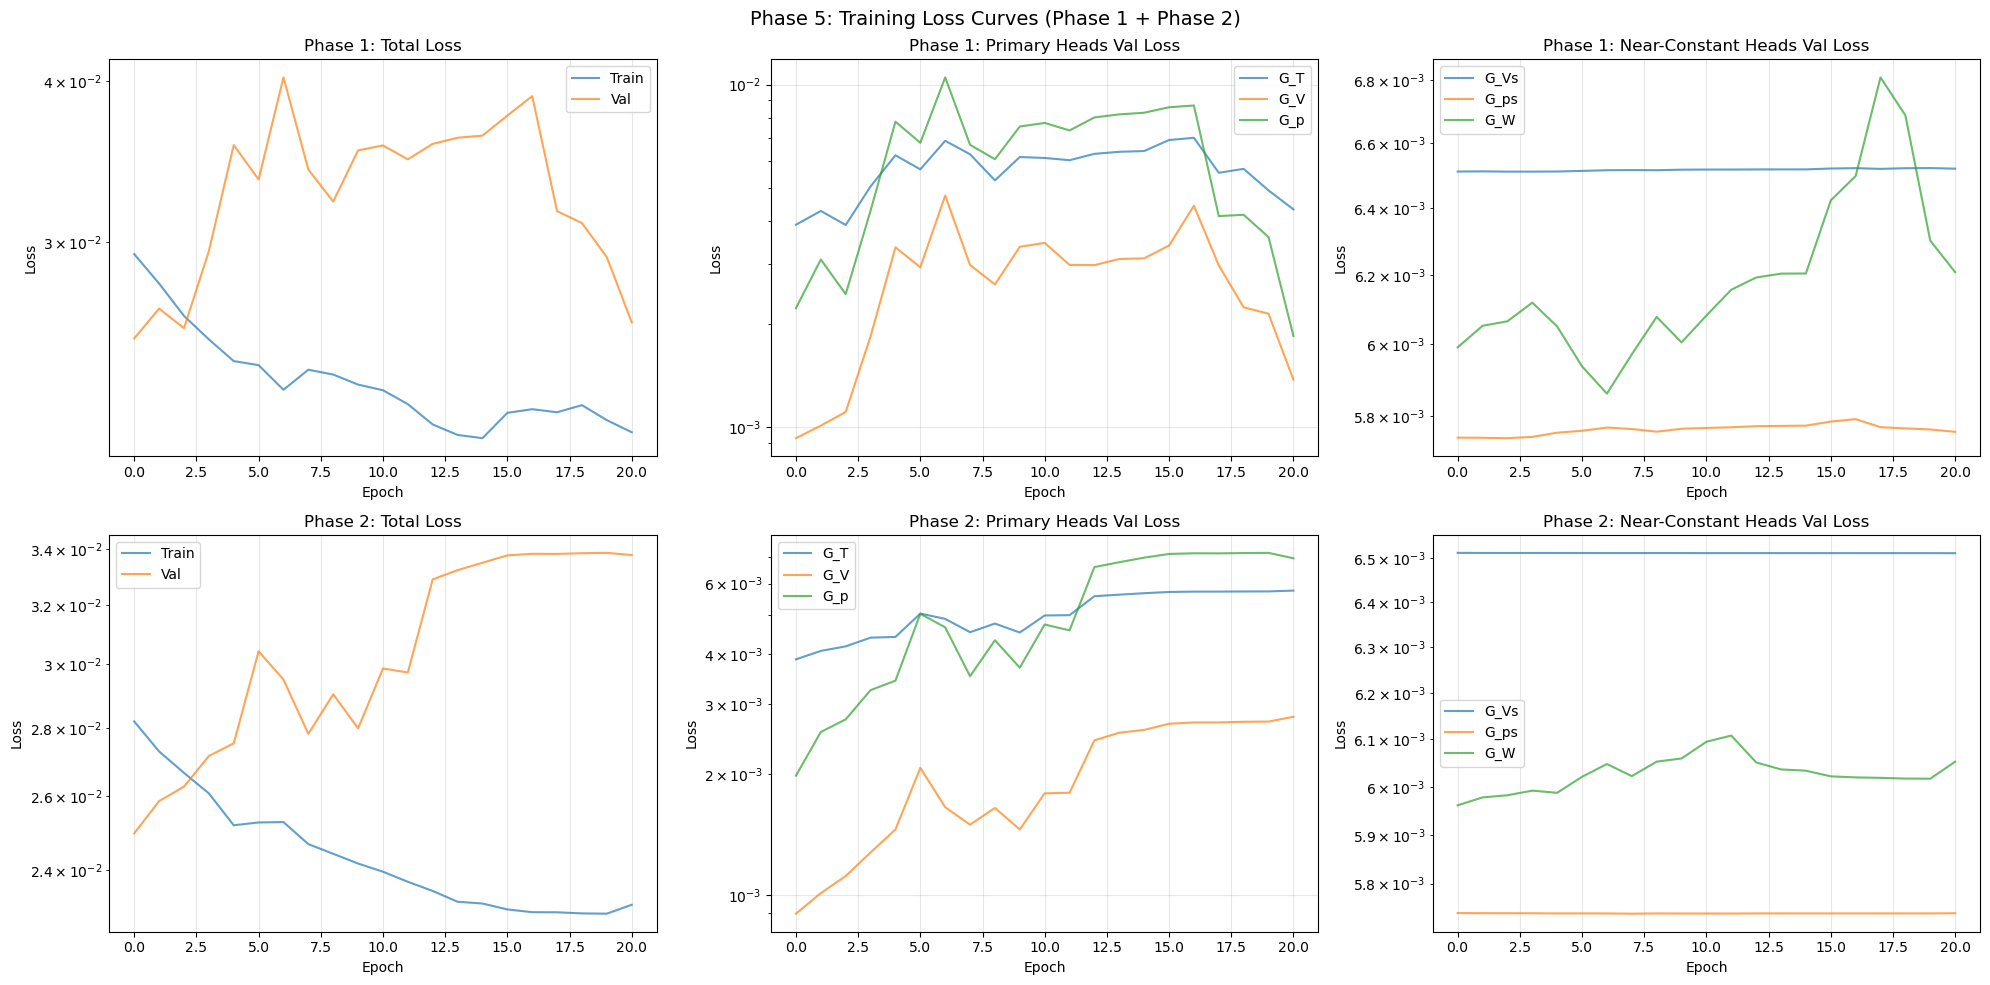

In [ ]:
#  Training Loss Curves — Phase 1 & Phase 2

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# --- Phase 1 ---
# Total loss
axes[0, 0].plot(phase1_history['train_total'], label='Train', alpha=0.7)
axes[0, 0].plot(phase1_history['val_total'], label='Val', alpha=0.7)
axes[0, 0].set_title('Phase 1: Total Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Primary heads validation
for head in ['G_T', 'G_V', 'G_p']:
    axes[0, 1].plot(phase1_history[f'val_{head}'], label=head, alpha=0.7)
axes[0, 1].set_title('Phase 1: Primary Heads Val Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Near-constant heads validation
for head in ['G_Vs', 'G_ps', 'G_W']:
    axes[0, 2].plot(phase1_history[f'val_{head}'], label=head, alpha=0.7)
axes[0, 2].set_title('Phase 1: Near-Constant Heads Val Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].legend()
axes[0, 2].set_yscale('log')
axes[0, 2].grid(True, alpha=0.3)

# --- Phase 2 ---
axes[1, 0].plot(phase2_history['train_total'], label='Train', alpha=0.7)
axes[1, 0].plot(phase2_history['val_total'], label='Val', alpha=0.7)
axes[1, 0].set_title('Phase 2: Total Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

for head in ['G_T', 'G_V', 'G_p']:
    axes[1, 1].plot(phase2_history[f'val_{head}'], label=head, alpha=0.7)
axes[1, 1].set_title('Phase 2: Primary Heads Val Loss')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

for head in ['G_Vs', 'G_ps', 'G_W']:
    axes[1, 2].plot(phase2_history[f'val_{head}'], label=head, alpha=0.7)
axes[1, 2].set_title('Phase 2: Near-Constant Heads Val Loss')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Loss')
axes[1, 2].legend()
axes[1, 2].set_yscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Phase 5: Training Loss Curves (Phase 1 + Phase 2)', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

### Performance Metrics (from Chapter 3)

**Primary Accuracy Measures:** MAE, RMSE, R², Variance Ratio, Correlation Coefficient

**Delta Prediction Metrics:** Delta Std Ratio, Cumulative Drift Error

**Comparison Metrics:** Persistence R², Skill Score, Beats Persistence flag

**Per-Head Analysis:** Performance breakdown by decoder head group (G_T, G_V, G_p, G_Vs, G_ps, G_W)

**Computational Performance:** Training time per phase, total epochs, model parameters, inference time

In [ ]:
#  Collect Test Predictions

@torch.no_grad()
def collect_predictions(model, loader, config, normalizer, column_info, device):
    """Run model on test loader and collect predictions + targets in absolute space."""
    model.eval()
    all_preds, all_targets, all_last_dyn, all_future_dyn = [], [], [], []

    for batch in tqdm(loader, desc="Collecting predictions", leave=False):
        u_hist = batch['u_hist'].to(device, non_blocking=True)
        y_hist = batch['y_hist'].to(device, non_blocking=True)

        output = model(u_hist, y_hist)
        predictions = output['predictions']  # (B, K, n_dynamic)

        all_preds.append(predictions.cpu().numpy())
        all_targets.append(batch['y_delta'].numpy())
        all_last_dyn.append(batch['last_dynamic'].numpy())
        all_future_dyn.append(batch['future_dynamic'].numpy())

    pred_norm = np.concatenate(all_preds)
    last_dyn = np.concatenate(all_last_dyn)
    future_dyn = np.concatenate(all_future_dyn)

    # Convert normalized deltas → absolute values
    dynamic_cols = column_info['dynamic_cols']
    pred_absolute = normalizer.inverse_delta(pred_norm, last_dyn, dynamic_cols)

    return {
        'pred_absolute': pred_absolute,
        'target_absolute': future_dyn,
        'pred_normalized': pred_norm,
        'target_normalized': np.concatenate(all_targets),
        'last_dynamic': last_dyn,
    }


print("Collecting test predictions...")
inference_start = time.time()
predictions_dict = collect_predictions(model, test_loader, config, normalizer, column_info, DEVICE)
inference_time = time.time() - inference_start
n_test_samples = predictions_dict['pred_absolute'].shape[0]

print(f"Predictions shape: {predictions_dict['pred_absolute'].shape}")
print(f"Inference time: {inference_time:.2f}s ({inference_time/n_test_samples*1000:.2f} ms/sample)")

Predictions shape: (174, 1, 2827)
Inference time: 1.44s (8.30 ms/sample)


In [ ]:
#  Compute Comprehensive Metrics (Chapter 3 Standard)

def compute_metrics(predictions_dict, column_info, config):
    """Compute per-output metrics matching Chapter 3 evaluation criteria."""
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_dyn = predictions_dict['last_dynamic']
    pred_norm = predictions_dict['pred_normalized']
    target_norm = predictions_dict['target_normalized']
    dynamic_cols = column_info['dynamic_cols']
    K = config.PREDICTION_STEPS

    # Build group lookup
    group_of_idx = {}
    for hname, indices in [
        ('G_T', column_info['temp_indices']),
        ('G_V', column_info['flow_indices']),
        ('G_p', column_info['pressure_indices']),
        ('G_Vs', column_info['flow_sec_indices']),
        ('G_ps', column_info['pressure_sec_indices']),
        ('G_W', column_info['power_indices']),
    ]:
        for idx in indices:
            group_of_idx[idx] = hname

    results = []
    for i, col in enumerate(dynamic_cols):
        p = pred[:, :, i].flatten()
        t = target[:, :, i].flatten()

        # Primary metrics
        mae = np.mean(np.abs(p - t))
        rmse = np.sqrt(np.mean((p - t) ** 2))
        ss_res = np.sum((t - p) ** 2)
        ss_tot = np.sum((t - t.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        # Variance ratio
        var_pred = np.var(p)
        var_true = np.var(t)
        variance_ratio = var_pred / (var_true + 1e-10)

        # Correlation coefficient
        if np.std(p) > 1e-10 and np.std(t) > 1e-10:
            correlation = np.corrcoef(p, t)[0, 1]
        else:
            correlation = 0.0

        # Delta metrics
        pred_d = pred_norm[:, :, i].flatten()
        targ_d = target_norm[:, :, i].flatten()
        delta_std_ratio = np.std(pred_d) / (np.std(targ_d) + 1e-10)

        # Cumulative drift (only meaningful for K > 1)
        cumulative_drift = 0.0
        if K > 1:
            cumulative_drift = np.mean(np.abs(pred[:, -1, i] - target[:, -1, i])) - \
                               np.mean(np.abs(pred[:, 0, i] - target[:, 0, i]))

        # Persistence baseline
        last_val = last_dyn[:, i]
        persistence = np.repeat(last_val[:, np.newaxis], K, axis=1).flatten()
        ss_res_pers = np.sum((t - persistence) ** 2)
        r2_pers = 1 - ss_res_pers / (ss_tot + 1e-10)
        skill_score = (r2 - r2_pers) / (1 - r2_pers + 1e-10)

        # Per-step R²
        step_r2 = []
        for k in range(K):
            pk = pred[:, k, i]
            tk = target[:, k, i]
            ss_res_k = np.sum((tk - pk) ** 2)
            ss_tot_k = np.sum((tk - tk.mean()) ** 2)
            step_r2.append(1 - ss_res_k / (ss_tot_k + 1e-10))

        cdu_id = column_info['col_to_cdu'].get(col, 'Unknown')
        output_type = column_info['col_to_type'].get(col, 'Unknown')
        group = group_of_idx.get(i, 'Unknown')

        # Determine loop classification
        loop = 'primary'
        if group in ['G_Vs', 'G_ps', 'G_W']:
            loop = 'secondary'
        elif output_type in ['T_sec_s_C', 'T_sec_r_C']:
            loop = 'secondary'

        results.append({
            'Output': col,
            'CDU': cdu_id,
            'Output_Type': output_type,
            'Group': group,
            'Loop': loop,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2,
            'Variance_Ratio': variance_ratio,
            'Correlation': correlation,
            'Delta_Std_Ratio': delta_std_ratio,
            'Cumulative_Drift': cumulative_drift,
            'Persistence_R2': r2_pers,
            'Beats_Persistence': r2 > r2_pers,
            'Skill_Score': skill_score,
            **{f'R2_step{k+1}': step_r2[k] for k in range(K)},
        })

    return pd.DataFrame(results)


metrics_df = compute_metrics(predictions_dict, column_info, config)
print(f"Metrics computed for {len(metrics_df)} outputs.")

Metrics computed for 2827 outputs.


In [ ]:
#  Results Summary — Overall, Per-Group, Per-Output-Type

print("\n" + "=" * 70)
print("RESULTS SUMMARY — Phase 5: Federated DeepM&Mnet")
print("=" * 70)

# Overall
print(f"\n--- All {len(metrics_df)} Outputs ---")
print(f"  Mean R²:           {metrics_df['R2'].mean():.4f}")
print(f"  Median R²:         {metrics_df['R2'].median():.4f}")
print(f"  Min R²:            {metrics_df['R2'].min():.4f}")
print(f"  Max R²:            {metrics_df['R2'].max():.4f}")
print(f"  Std R²:            {metrics_df['R2'].std():.4f}")
print(f"  Beats Persistence: {metrics_df['Beats_Persistence'].sum()}/{len(metrics_df)} "
      f"({metrics_df['Beats_Persistence'].mean():.1%})")
print(f"  Mean Skill Score:  {metrics_df['Skill_Score'].mean():.4f}")

# Per-group summary
print(f"\n--- Per Decoder Head Group ---")
for group in ALL_HEAD_NAMES:
    grp = metrics_df[metrics_df['Group'] == group]
    if len(grp) == 0:
        continue
    head_type = column_info['head_groups'][group]['type']
    print(f"\n  {group} ({head_type}, {len(grp)} outputs):")
    print(f"    Mean R²:         {grp['R2'].mean():.4f}")
    print(f"    Median R²:       {grp['R2'].median():.4f}")
    print(f"    Variance Ratio:  {grp['Variance_Ratio'].mean():.4f}")
    print(f"    Mean Correlation:{grp['Correlation'].mean():.4f}")
    print(f"    Beats Persist:   {grp['Beats_Persistence'].sum()}/{len(grp)} "
          f"({grp['Beats_Persistence'].mean():.1%})")

# Per output-type summary
print(f"\n--- Per Output Type ---")
output_types = config.ALL_DYNAMIC_OUTPUTS
type_summary = metrics_df.groupby('Output_Type').agg({
    'R2': ['mean', 'median', 'min', 'max'],
    'RMSE': 'mean',
    'MAE': 'mean',
    'Variance_Ratio': 'mean',
    'Correlation': 'mean',
    'Beats_Persistence': 'mean',
}).round(4)
print(type_summary.to_string())

# R² distribution
print(f"\n--- R² Distribution ---")
for threshold, label in [(0.99, '≥ 0.99'), (0.95, '≥ 0.95'), (0.90, '≥ 0.90'),
                          (0.80, '≥ 0.80'), (0.50, '≥ 0.50'), (0.0, '≥ 0.00')]:
    count = (metrics_df['R2'] >= threshold).sum()
    print(f"  R² {label}: {count}/{len(metrics_df)} ({count/len(metrics_df):.1%})")
count_neg = (metrics_df['R2'] < 0).sum()
print(f"  R² < 0.00: {count_neg}/{len(metrics_df)} ({count_neg/len(metrics_df):.1%})")

# Computational summary
print(f"\n--- Computational Performance ---")
print(f"  Model Parameters:     {total_params:,}")
print(f"  Phase 1 Epochs:       {phase1_epochs}")
print(f"  Phase 2 Epochs:       {phase2_epochs}")
print(f"  Total Epochs:         {total_epochs}")
print(f"  Phase 1 Time:         {phase1_time:.1f}s ({phase1_time/60:.1f} min)")
print(f"  Phase 2 Time:         {phase2_time:.1f}s ({phase2_time/60:.1f} min)")
print(f"  Total Training Time:  {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"  Inference Time:       {inference_time:.2f}s")
print(f"  Per sample:           {inference_time/n_test_samples*1000:.2f} ms")


RESULTS SUMMARY — Phase 5: Federated DeepM&Mnet

--- All 2827 Outputs ---
  Mean R²:           0.9632
  Median R²:         0.9926
  Min R²:            0.2286
  Max R²:            0.9995
  Std R²:            0.0720
  Beats Persistence: 1005/2827 (35.6%)
  Mean Skill Score:  -0.0191

--- Per Decoder Head Group ---

  G_T (standard, 1028 outputs):
    Mean R²:         0.9924
    Median R²:       0.9942
    Variance Ratio:  0.9958
    Mean Correlation:0.9963
    Beats Persist:   414/1028 (40.3%)

  G_V (standard, 257 outputs):
    Mean R²:         0.9810
    Median R²:       0.9811
    Variance Ratio:  0.9880
    Mean Correlation:0.9905
    Beats Persist:   225/257 (87.5%)

  G_p (standard, 514 outputs):
    Mean R²:         0.9931
    Median R²:       0.9931
    Variance Ratio:  0.9871
    Mean Correlation:0.9966
    Beats Persist:   34/514 (6.6%)

  G_Vs (skip, 257 outputs):
    Mean R²:         0.8123
    Median R²:       0.8502
    Variance Ratio:  1.0035
    Mean Correlation:0.9064
 

## Evaluation Metric Visualizations

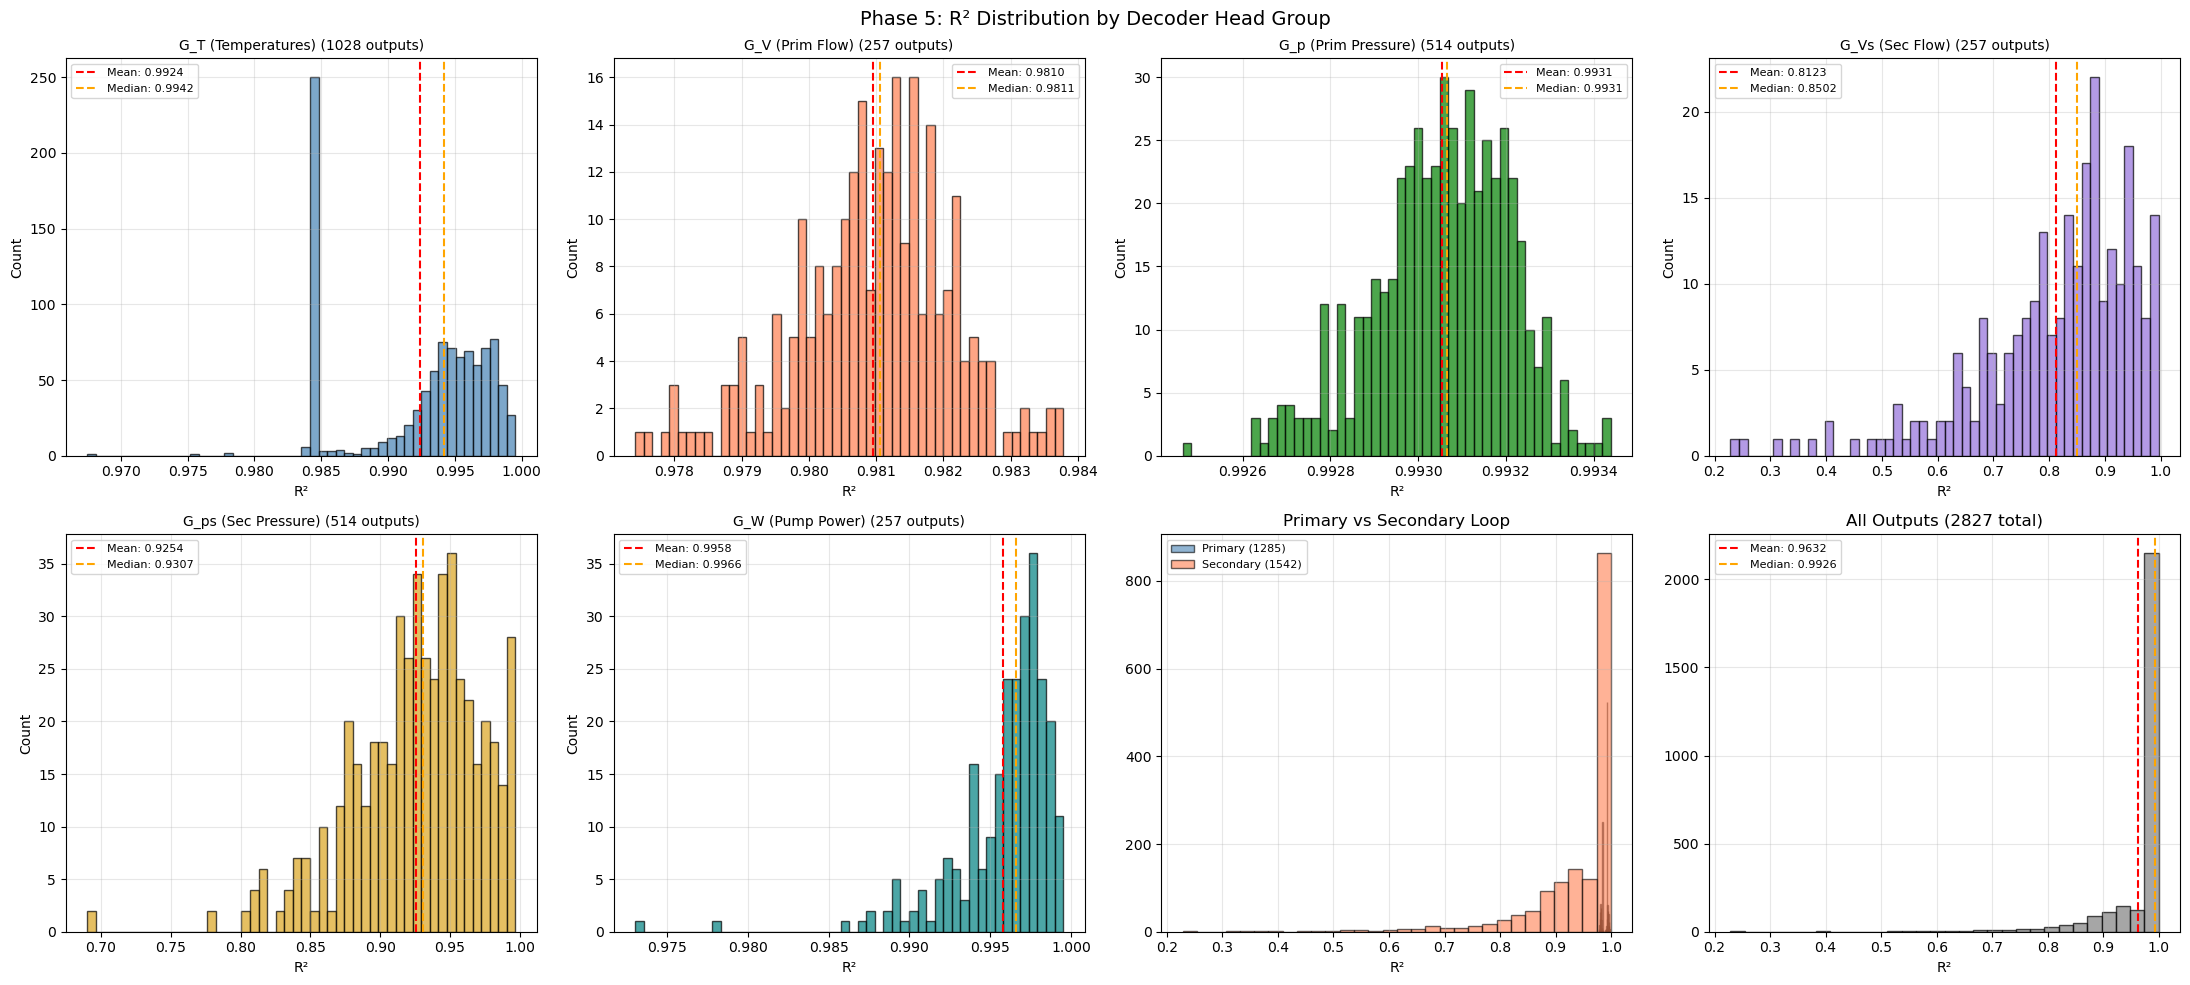

In [ ]:
#  Visualization 1 — R² Distribution by Decoder Head Group

os.makedirs('phase_5_vis', exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

group_names = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
group_labels = ['G_T (Temperatures)', 'G_V (Prim Flow)', 'G_p (Prim Pressure)',
                'G_Vs (Sec Flow)', 'G_ps (Sec Pressure)', 'G_W (Pump Power)']
colors = ['steelblue', 'coral', 'green', 'mediumpurple', 'goldenrod', 'teal']

for idx, (group, label, color) in enumerate(zip(group_names, group_labels, colors)):
    ax = axes[idx]
    group_data = metrics_df[metrics_df['Group'] == group]['R2']
    if len(group_data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(group_data, bins=min(50, len(group_data)), alpha=0.7,
            edgecolor='black', color=color)
    ax.axvline(group_data.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {group_data.mean():.4f}')
    ax.axvline(group_data.median(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Median: {group_data.median():.4f}')
    ax.set_title(f'{label} ({len(group_data)} outputs)', fontsize=10)
    ax.set_xlabel('R²')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Primary vs Secondary
ax = axes[6]
prim = metrics_df[metrics_df['Loop'] == 'primary']['R2']
sec = metrics_df[metrics_df['Loop'] == 'secondary']['R2']
ax.hist(prim, bins=30, alpha=0.6, label=f'Primary ({len(prim)})', color='steelblue', edgecolor='black')
ax.hist(sec, bins=30, alpha=0.6, label=f'Secondary ({len(sec)})', color='coral', edgecolor='black')
ax.set_title('Primary vs Secondary Loop')
ax.set_xlabel('R²')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Overall
ax = axes[7]
ax.hist(metrics_df['R2'], bins=30, alpha=0.7, edgecolor='black', color='gray')
ax.axvline(metrics_df['R2'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {metrics_df["R2"].mean():.4f}')
ax.axvline(metrics_df['R2'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {metrics_df["R2"].median():.4f}')
ax.set_title(f'All Outputs ({len(metrics_df)} total)')
ax.set_xlabel('R²')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 5: R² Distribution by Decoder Head Group', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/r2_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

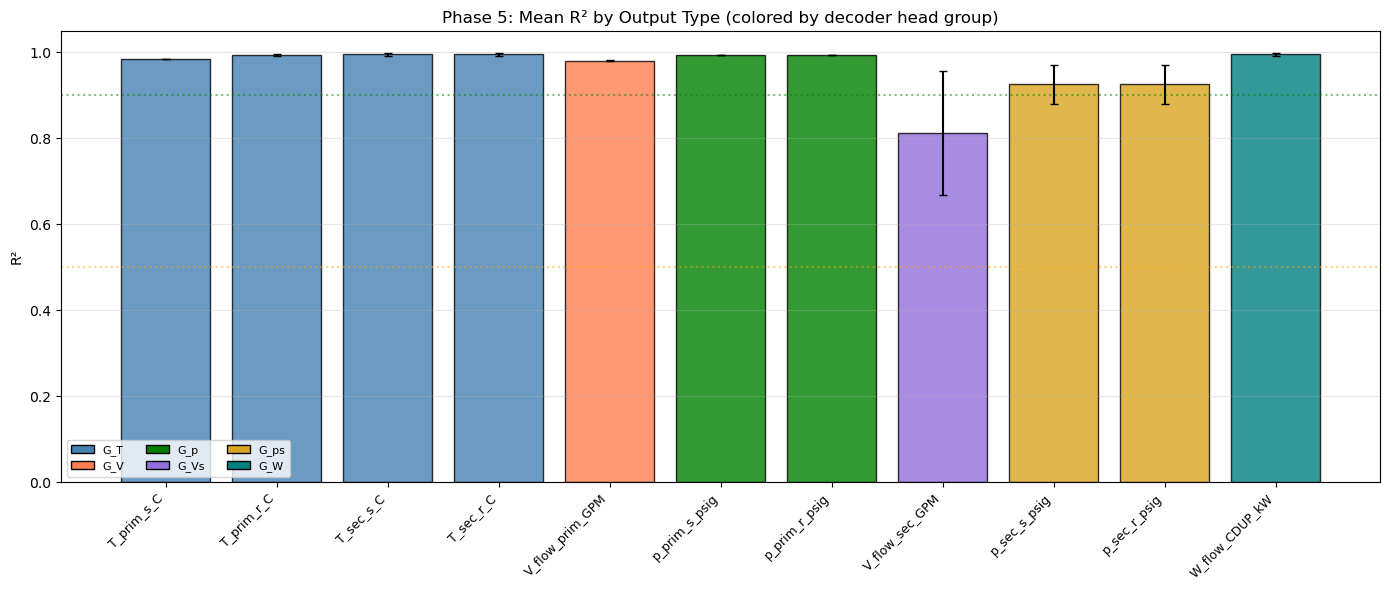

In [ ]:
#  Visualization 2 — Per-Output-Type R² Bar Chart

output_types = config.ALL_DYNAMIC_OUTPUTS
r2_means = []
r2_stds = []
group_colors_map = {
    'G_T': 'steelblue', 'G_V': 'coral', 'G_p': 'green',
    'G_Vs': 'mediumpurple', 'G_ps': 'goldenrod', 'G_W': 'teal'
}

fig, ax = plt.subplots(figsize=(14, 6))
for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_r2 = subset['R2'].mean()
    std_r2 = subset['R2'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax.bar(i, mean_r2, yerr=std_r2, color=color, edgecolor='black',
           alpha=0.8, capsize=3)

ax.set_xticks(range(len(output_types)))
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('R²')
ax.set_title('Phase 5: Mean R² by Output Type (colored by decoder head group)')
ax.axhline(y=0.9, color='green', linestyle=':', alpha=0.5, label='R²=0.9')
ax.axhline(y=0.5, color='orange', linestyle=':', alpha=0.5, label='R²=0.5')

# Legend for groups
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=g)
                   for g, c in group_colors_map.items()]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, ncol=3)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_5_vis/r2_by_output_type.png', dpi=150, bbox_inches='tight')
plt.show()

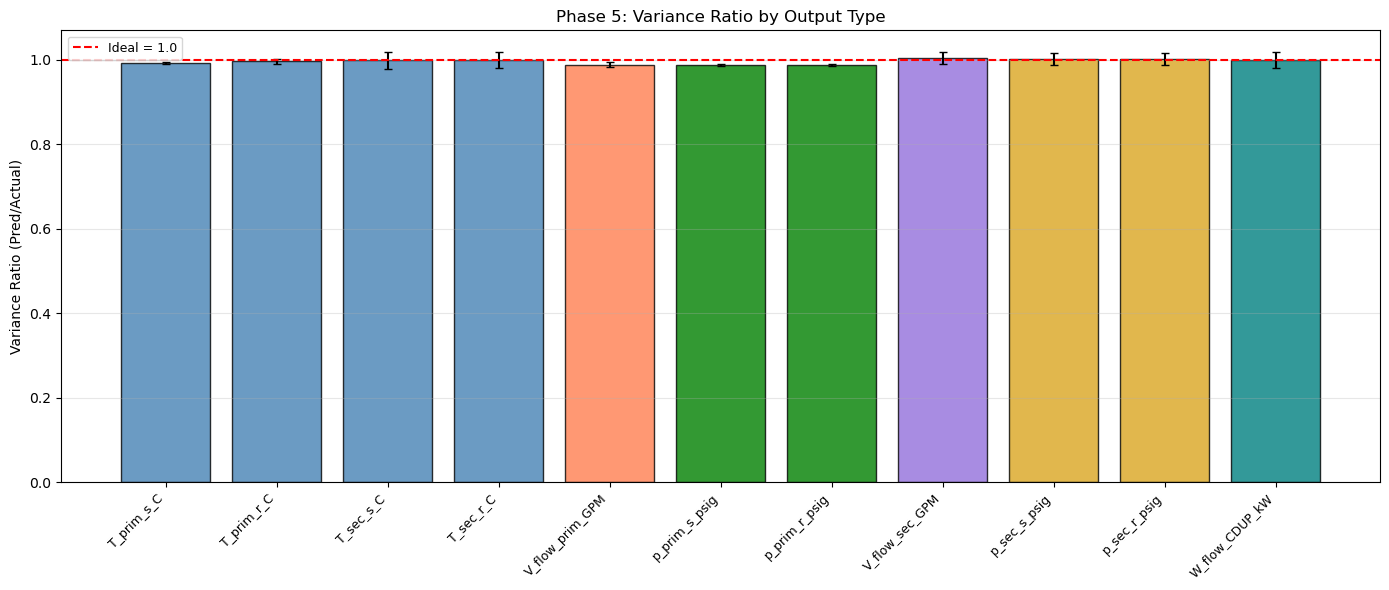

In [ ]:
#  Visualization 3 — Variance Ratio by Output Type

fig, ax = plt.subplots(figsize=(14, 6))

for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_vr = subset['Variance_Ratio'].mean()
    std_vr = subset['Variance_Ratio'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax.bar(i, mean_vr, yerr=std_vr, color=color, edgecolor='black',
           alpha=0.8, capsize=3)

ax.set_xticks(range(len(output_types)))
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Variance Ratio (Pred/Actual)')
ax.set_title('Phase 5: Variance Ratio by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Ideal = 1.0')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_5_vis/variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

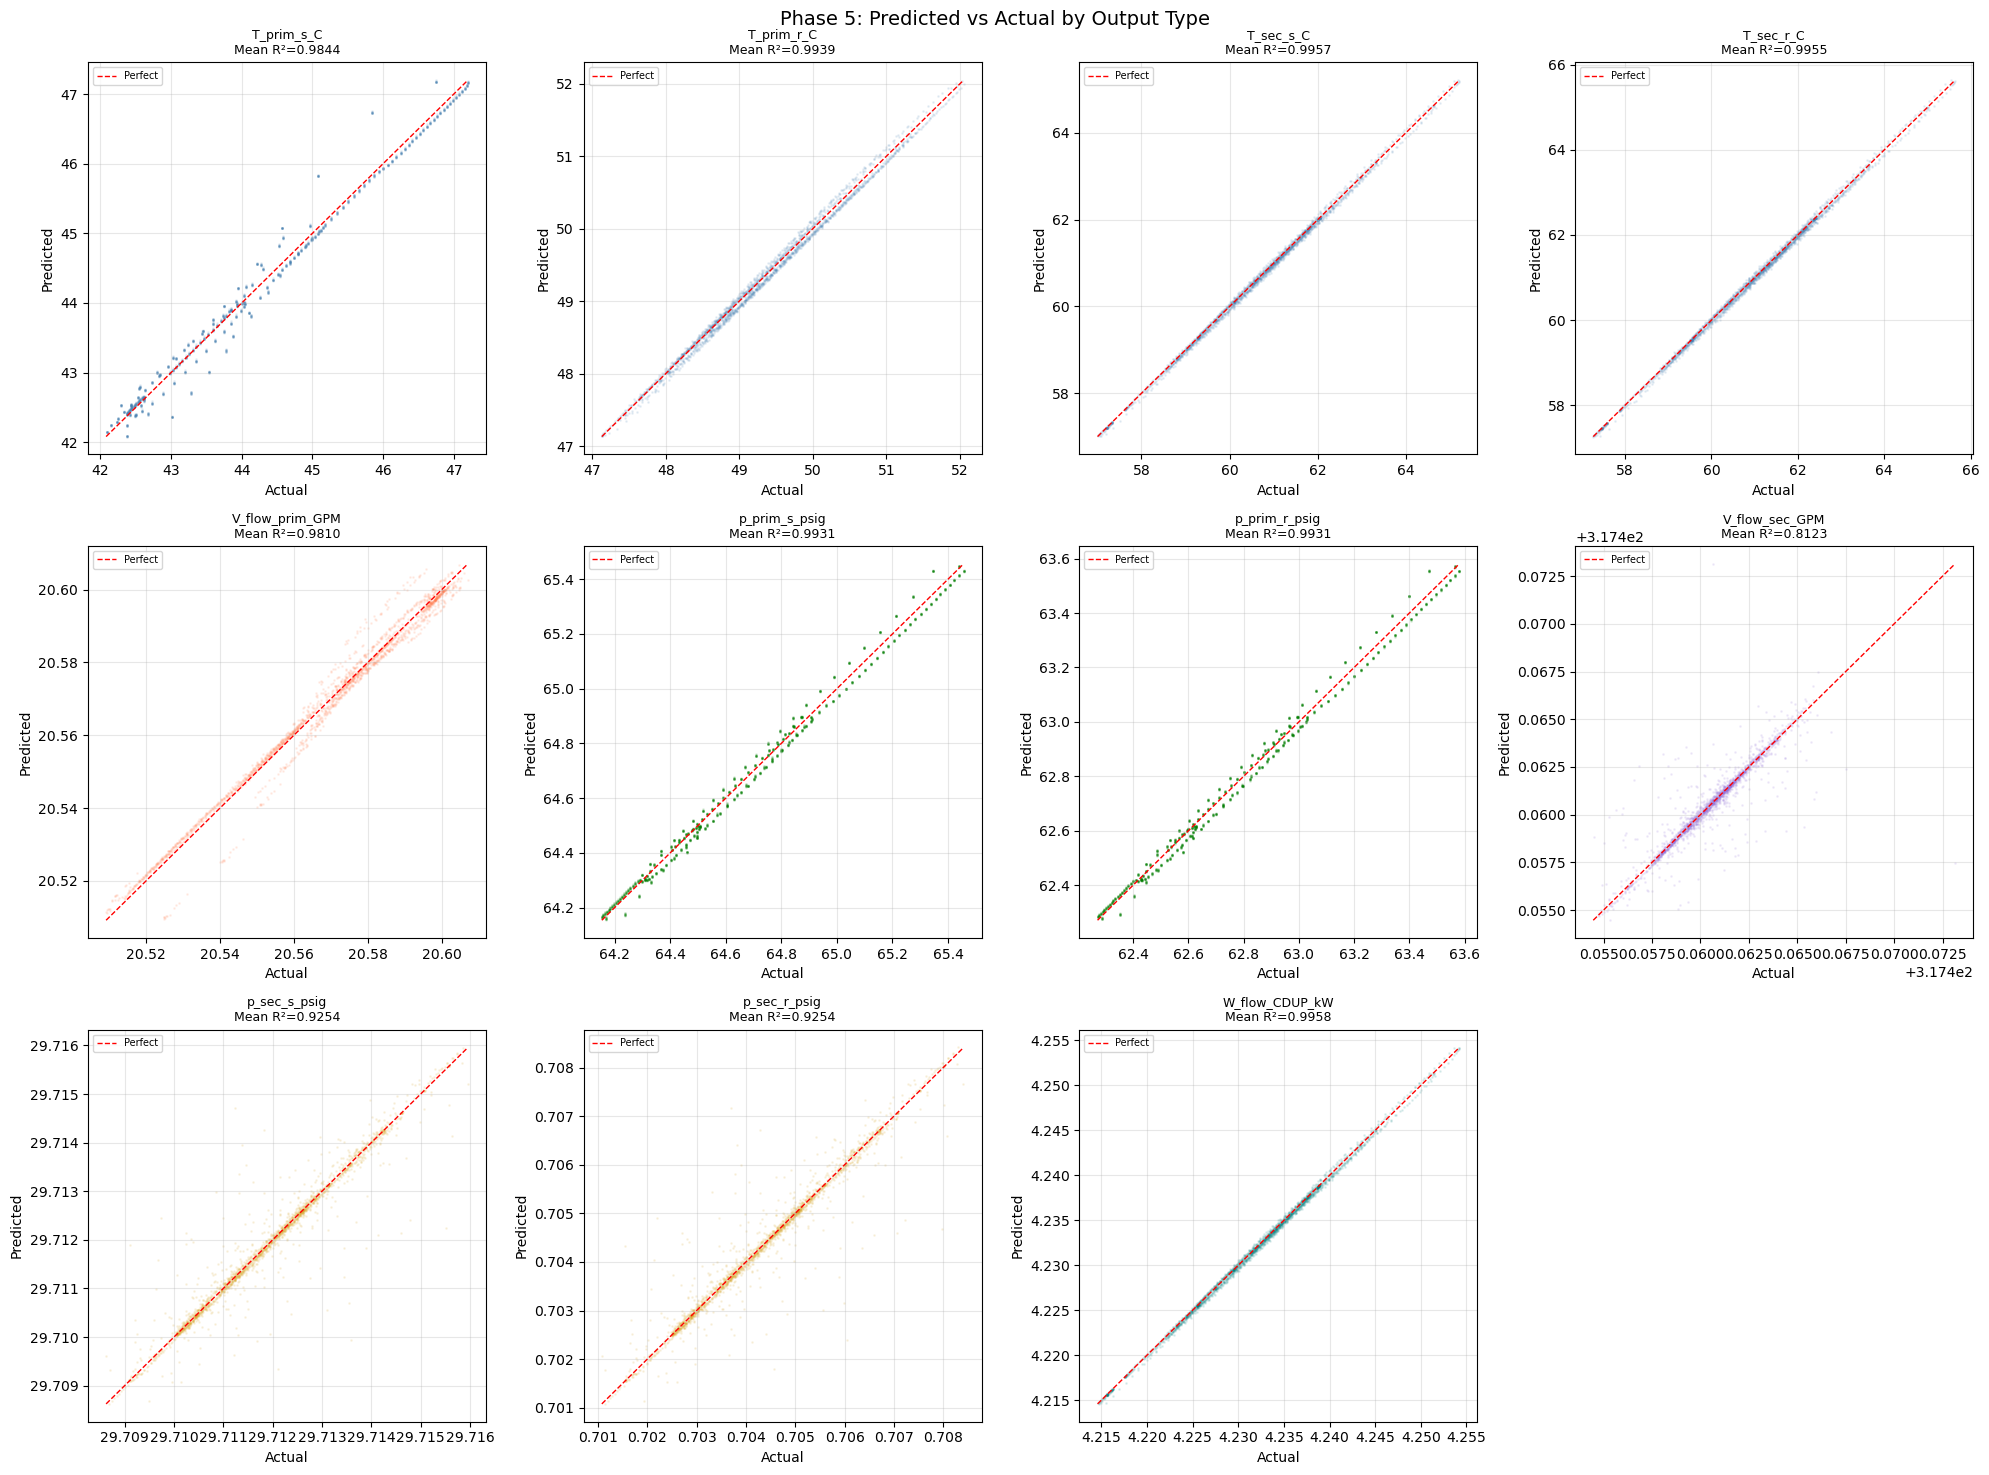

In [ ]:
#  Visualization 4 — Scatter Plots (Predicted vs Actual) per Output Type

n_types = len(output_types)
ncols = 4
nrows = (n_types + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

pred_abs = predictions_dict['pred_absolute']     # (N, K, n_dynamic)
tgt_abs = predictions_dict['target_absolute']    # (N, K, n_dynamic)

for idx, otype in enumerate(output_types):
    ax = axes[idx]
    # Find column indices for this output type
    type_cols = [i for i, col in enumerate(column_info['dynamic_cols'])
                 if otype in col]
    if not type_cols:
        ax.set_visible(False)
        continue

    # Sample CDUs for scatter
    sample_cols = type_cols[::max(1, len(type_cols)//10)]  # up to 10 CDUs
    pred_vals = pred_abs[:, :, sample_cols].flatten()
    tgt_vals = tgt_abs[:, :, sample_cols].flatten()

    ax.scatter(tgt_vals, pred_vals, alpha=0.1, s=1, color=group_colors_map.get(
        metrics_df[metrics_df['Output_Type'] == otype]['Group'].iloc[0], 'gray'))
    lims = [min(tgt_vals.min(), pred_vals.min()), max(tgt_vals.max(), pred_vals.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')

    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_r2 = subset['R2'].mean()
    ax.set_title(f'{otype}\nMean R²={mean_r2:.4f}', fontsize=9)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide empty subplots
for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 5: Predicted vs Actual by Output Type', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/scatter_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

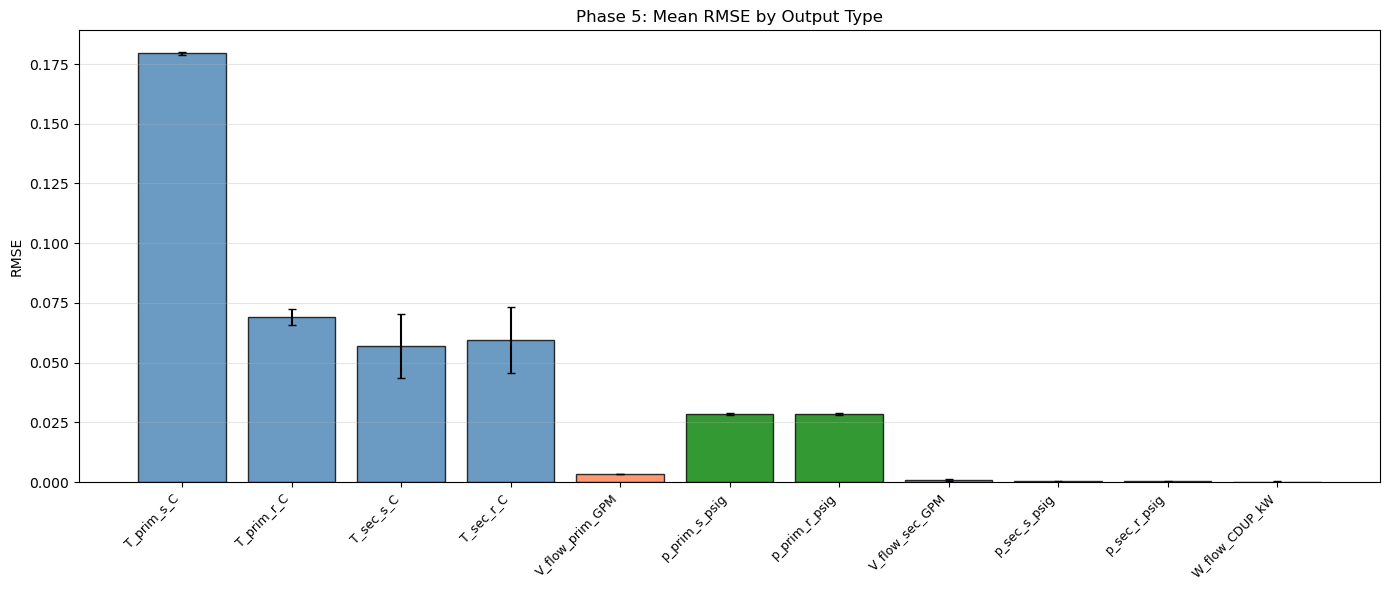

In [ ]:
#  Visualization 5 — RMSE by Output Type

fig, ax = plt.subplots(figsize=(14, 6))

for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_rmse = subset['RMSE'].mean()
    std_rmse = subset['RMSE'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax.bar(i, mean_rmse, yerr=std_rmse, color=color, edgecolor='black',
           alpha=0.8, capsize=3)

ax.set_xticks(range(len(output_types)))
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('RMSE')
ax.set_title('Phase 5: Mean RMSE by Output Type')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('phase_5_vis/rmse_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

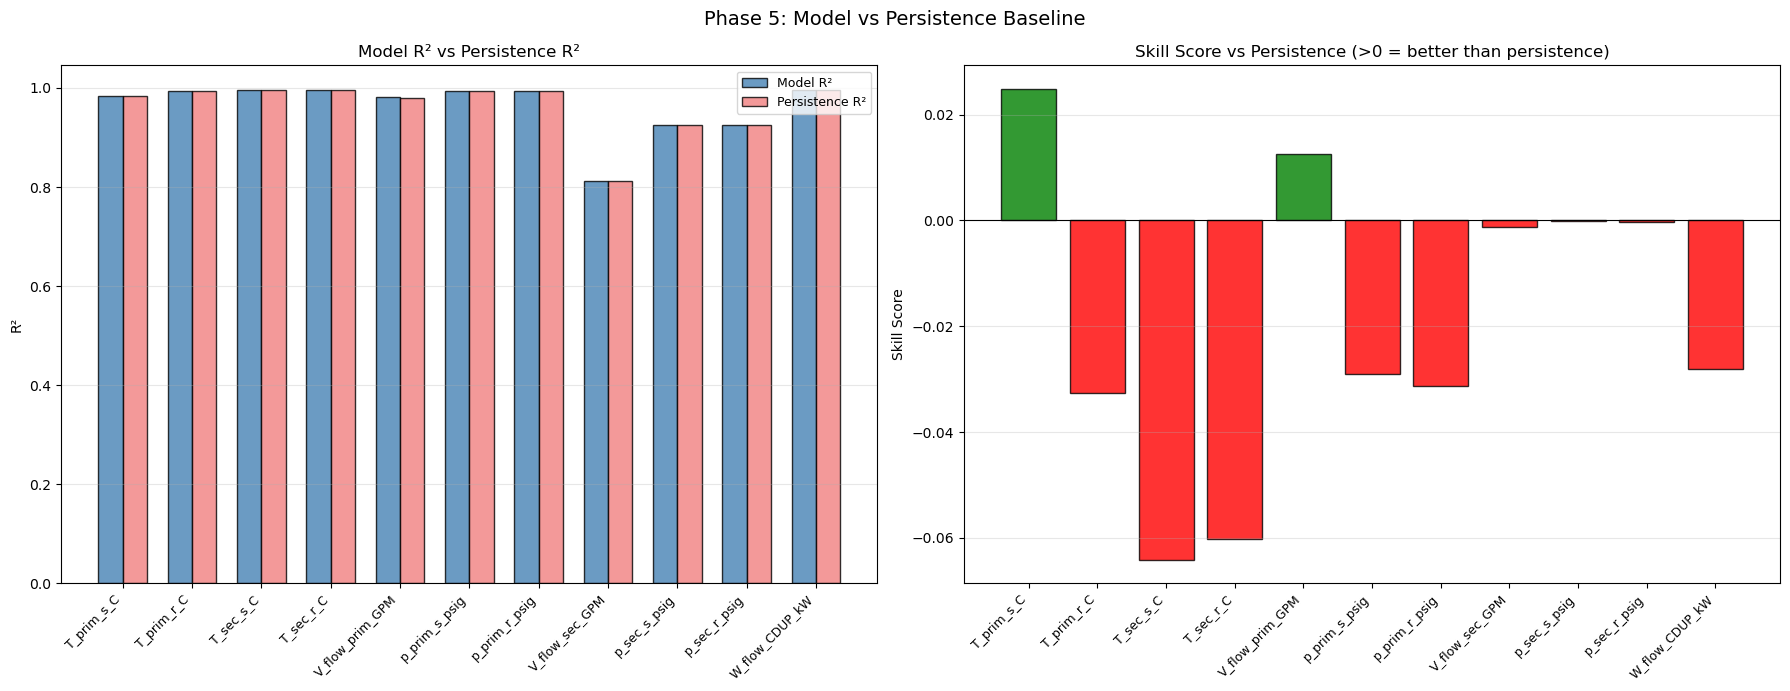

In [ ]:
#  Visualization 6 — Model vs Persistence (R² and Skill Score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: R² comparison
x = np.arange(len(output_types))
width = 0.35

model_r2 = [metrics_df[metrics_df['Output_Type'] == ot]['R2'].mean() for ot in output_types]
pers_r2 = [metrics_df[metrics_df['Output_Type'] == ot]['Persistence_R2'].mean() for ot in output_types]

bars1 = ax1.bar(x - width/2, model_r2, width, label='Model R²', color='steelblue',
                edgecolor='black', alpha=0.8)
bars2 = ax1.bar(x + width/2, pers_r2, width, label='Persistence R²', color='lightcoral',
                edgecolor='black', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('R²')
ax1.set_title('Model R² vs Persistence R²')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# Right: Skill Score
skill_scores = [metrics_df[metrics_df['Output_Type'] == ot]['Skill_Score'].mean()
                for ot in output_types]
colors_skill = ['green' if s > 0 else 'red' for s in skill_scores]
ax2.bar(x, skill_scores, color=colors_skill, edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Skill Score')
ax2.set_title('Skill Score vs Persistence (>0 = better than persistence)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Phase 5: Model vs Persistence Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/model_vs_persistence.png', dpi=150, bbox_inches='tight')
plt.show()

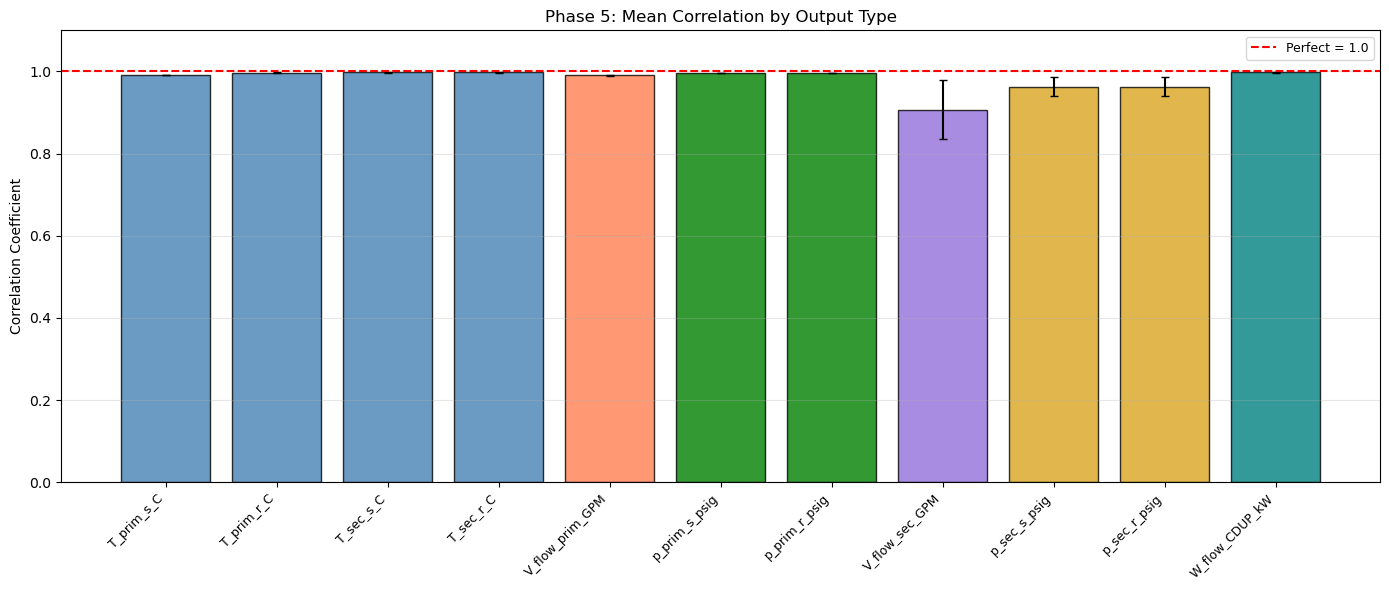

In [ ]:
#  Visualization 7 — Correlation Coefficient by Output Type

fig, ax = plt.subplots(figsize=(14, 6))

for i, otype in enumerate(output_types):
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    mean_corr = subset['Correlation'].mean()
    std_corr = subset['Correlation'].std()
    group = subset['Group'].iloc[0] if len(subset) > 0 else 'G_T'
    color = group_colors_map.get(group, 'gray')
    ax.bar(i, mean_corr, yerr=std_corr, color=color, edgecolor='black',
           alpha=0.8, capsize=3)

ax.set_xticks(range(len(output_types)))
ax.set_xticklabels(output_types, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Phase 5: Mean Correlation by Output Type')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='Perfect = 1.0')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('phase_5_vis/correlation.png', dpi=150, bbox_inches='tight')
plt.show()

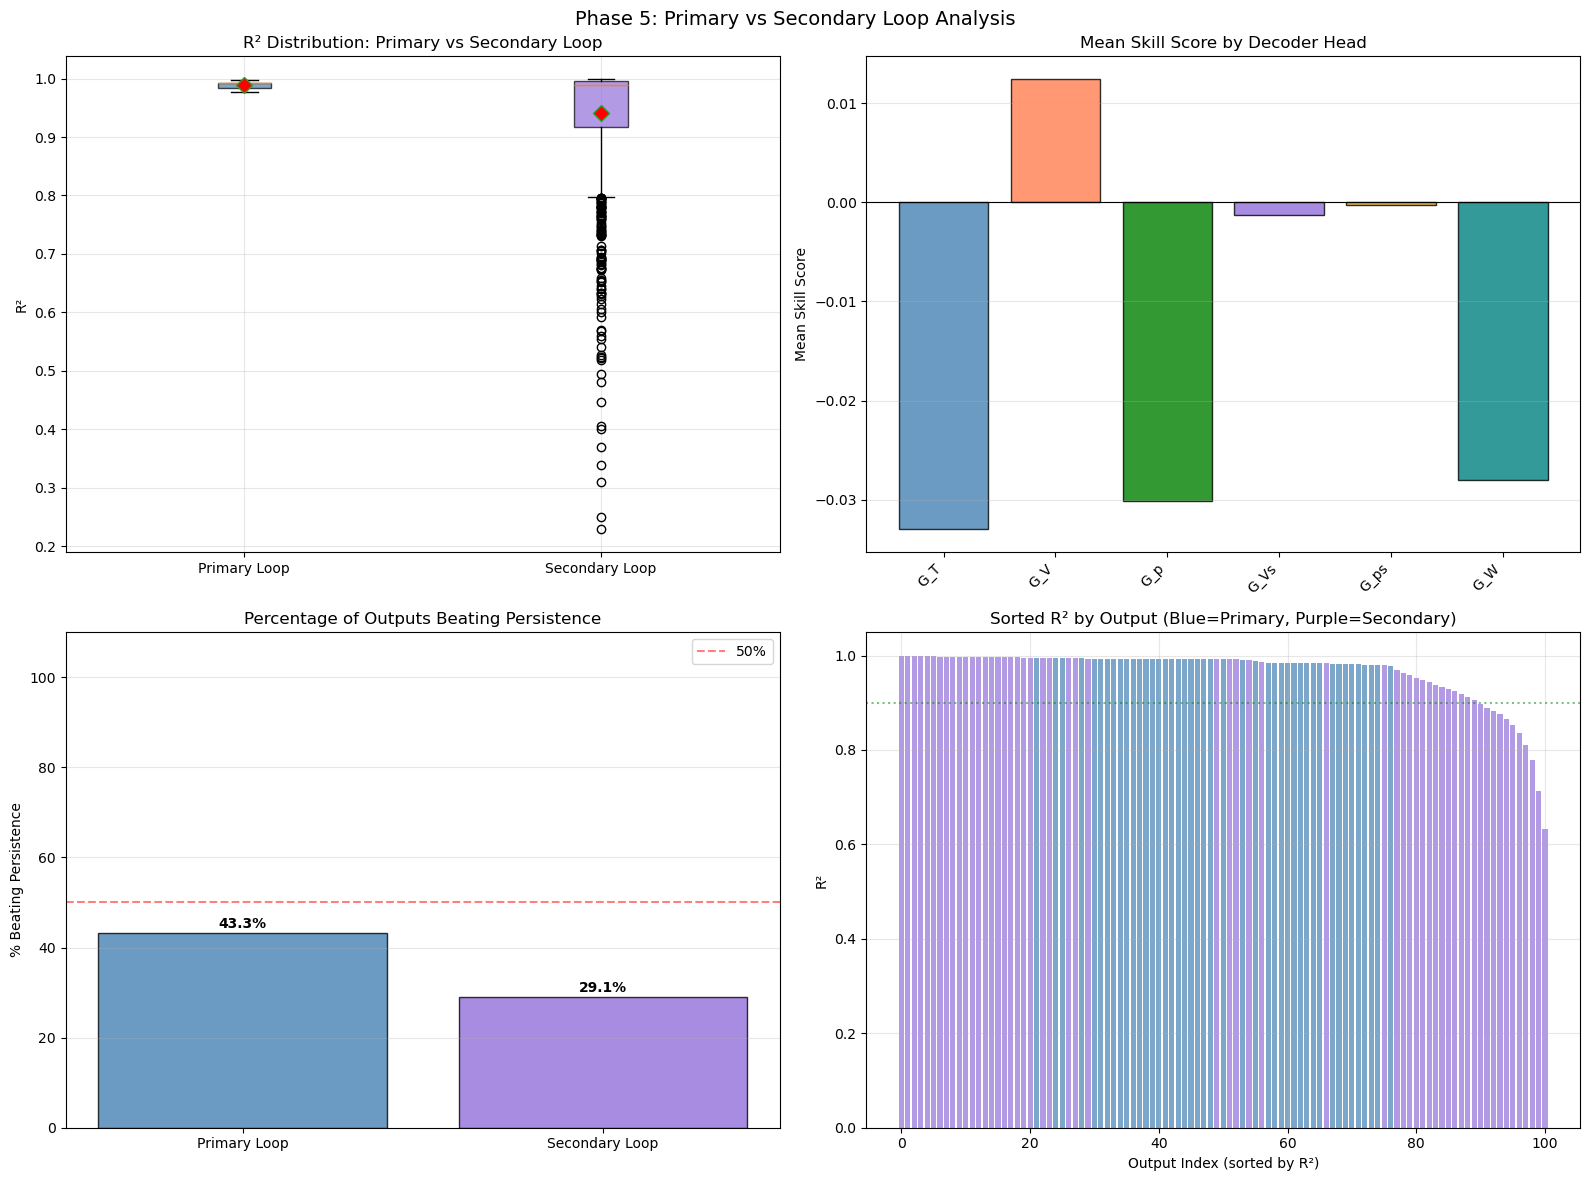

In [ ]:
#  Visualization 8 — Primary vs Secondary Loop Dichotomy

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

primary_df = metrics_df[metrics_df['Loop'] == 'primary']
secondary_df = metrics_df[metrics_df['Loop'] == 'secondary']

# (a) R² Boxplots by Loop
ax = axes[0, 0]
data_box = [primary_df['R2'].values, secondary_df['R2'].values]
bp = ax.boxplot(data_box, labels=['Primary Loop', 'Secondary Loop'],
                patch_artist=True, showmeans=True,
                meanprops={'marker': 'D', 'markerfacecolor': 'red', 'markersize': 8})
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('mediumpurple')
for box in bp['boxes']:
    box.set_alpha(0.7)
ax.set_ylabel('R²')
ax.set_title('R² Distribution: Primary vs Secondary Loop')
ax.grid(True, alpha=0.3)

# (b) Mean Skill Score by Group
ax = axes[0, 1]
group_names_sorted = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
skill_by_group = [metrics_df[metrics_df['Group'] == g]['Skill_Score'].mean()
                  for g in group_names_sorted]
colors_bar = [group_colors_map[g] for g in group_names_sorted]
ax.bar(range(len(group_names_sorted)), skill_by_group, color=colors_bar,
       edgecolor='black', alpha=0.8)
ax.set_xticks(range(len(group_names_sorted)))
ax.set_xticklabels(group_names_sorted, rotation=45, ha='right')
ax.set_ylabel('Mean Skill Score')
ax.set_title('Mean Skill Score by Decoder Head')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')

# (c) Beats Persistence %
ax = axes[1, 0]
beats_prim = primary_df['Beats_Persistence'].mean() * 100
beats_sec = secondary_df['Beats_Persistence'].mean() * 100
ax.bar(['Primary Loop', 'Secondary Loop'], [beats_prim, beats_sec],
       color=['steelblue', 'mediumpurple'], edgecolor='black', alpha=0.8)
ax.set_ylabel('% Beating Persistence')
ax.set_title('Percentage of Outputs Beating Persistence')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
for i, v in enumerate([beats_prim, beats_sec]):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (d) Sorted R² by Output (colored by loop)
ax = axes[1, 1]
sorted_df = metrics_df.sort_values('R2', ascending=False)
# Sample every Nth for readability
sample_step = max(1, len(sorted_df) // 100)
sampled = sorted_df.iloc[::sample_step]
colors_sorted = ['steelblue' if l == 'primary' else 'mediumpurple'
                 for l in sampled['Loop']]
ax.bar(range(len(sampled)), sampled['R2'].values, color=colors_sorted, alpha=0.7)
ax.set_xlabel('Output Index (sorted by R²)')
ax.set_ylabel('R²')
ax.set_title('Sorted R² by Output (Blue=Primary, Purple=Secondary)')
ax.axhline(y=0.9, color='green', linestyle=':', alpha=0.5)
ax.grid(True, alpha=0.3)

plt.suptitle('Phase 5: Primary vs Secondary Loop Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/loop_dichotomy.png', dpi=150, bbox_inches='tight')
plt.show()

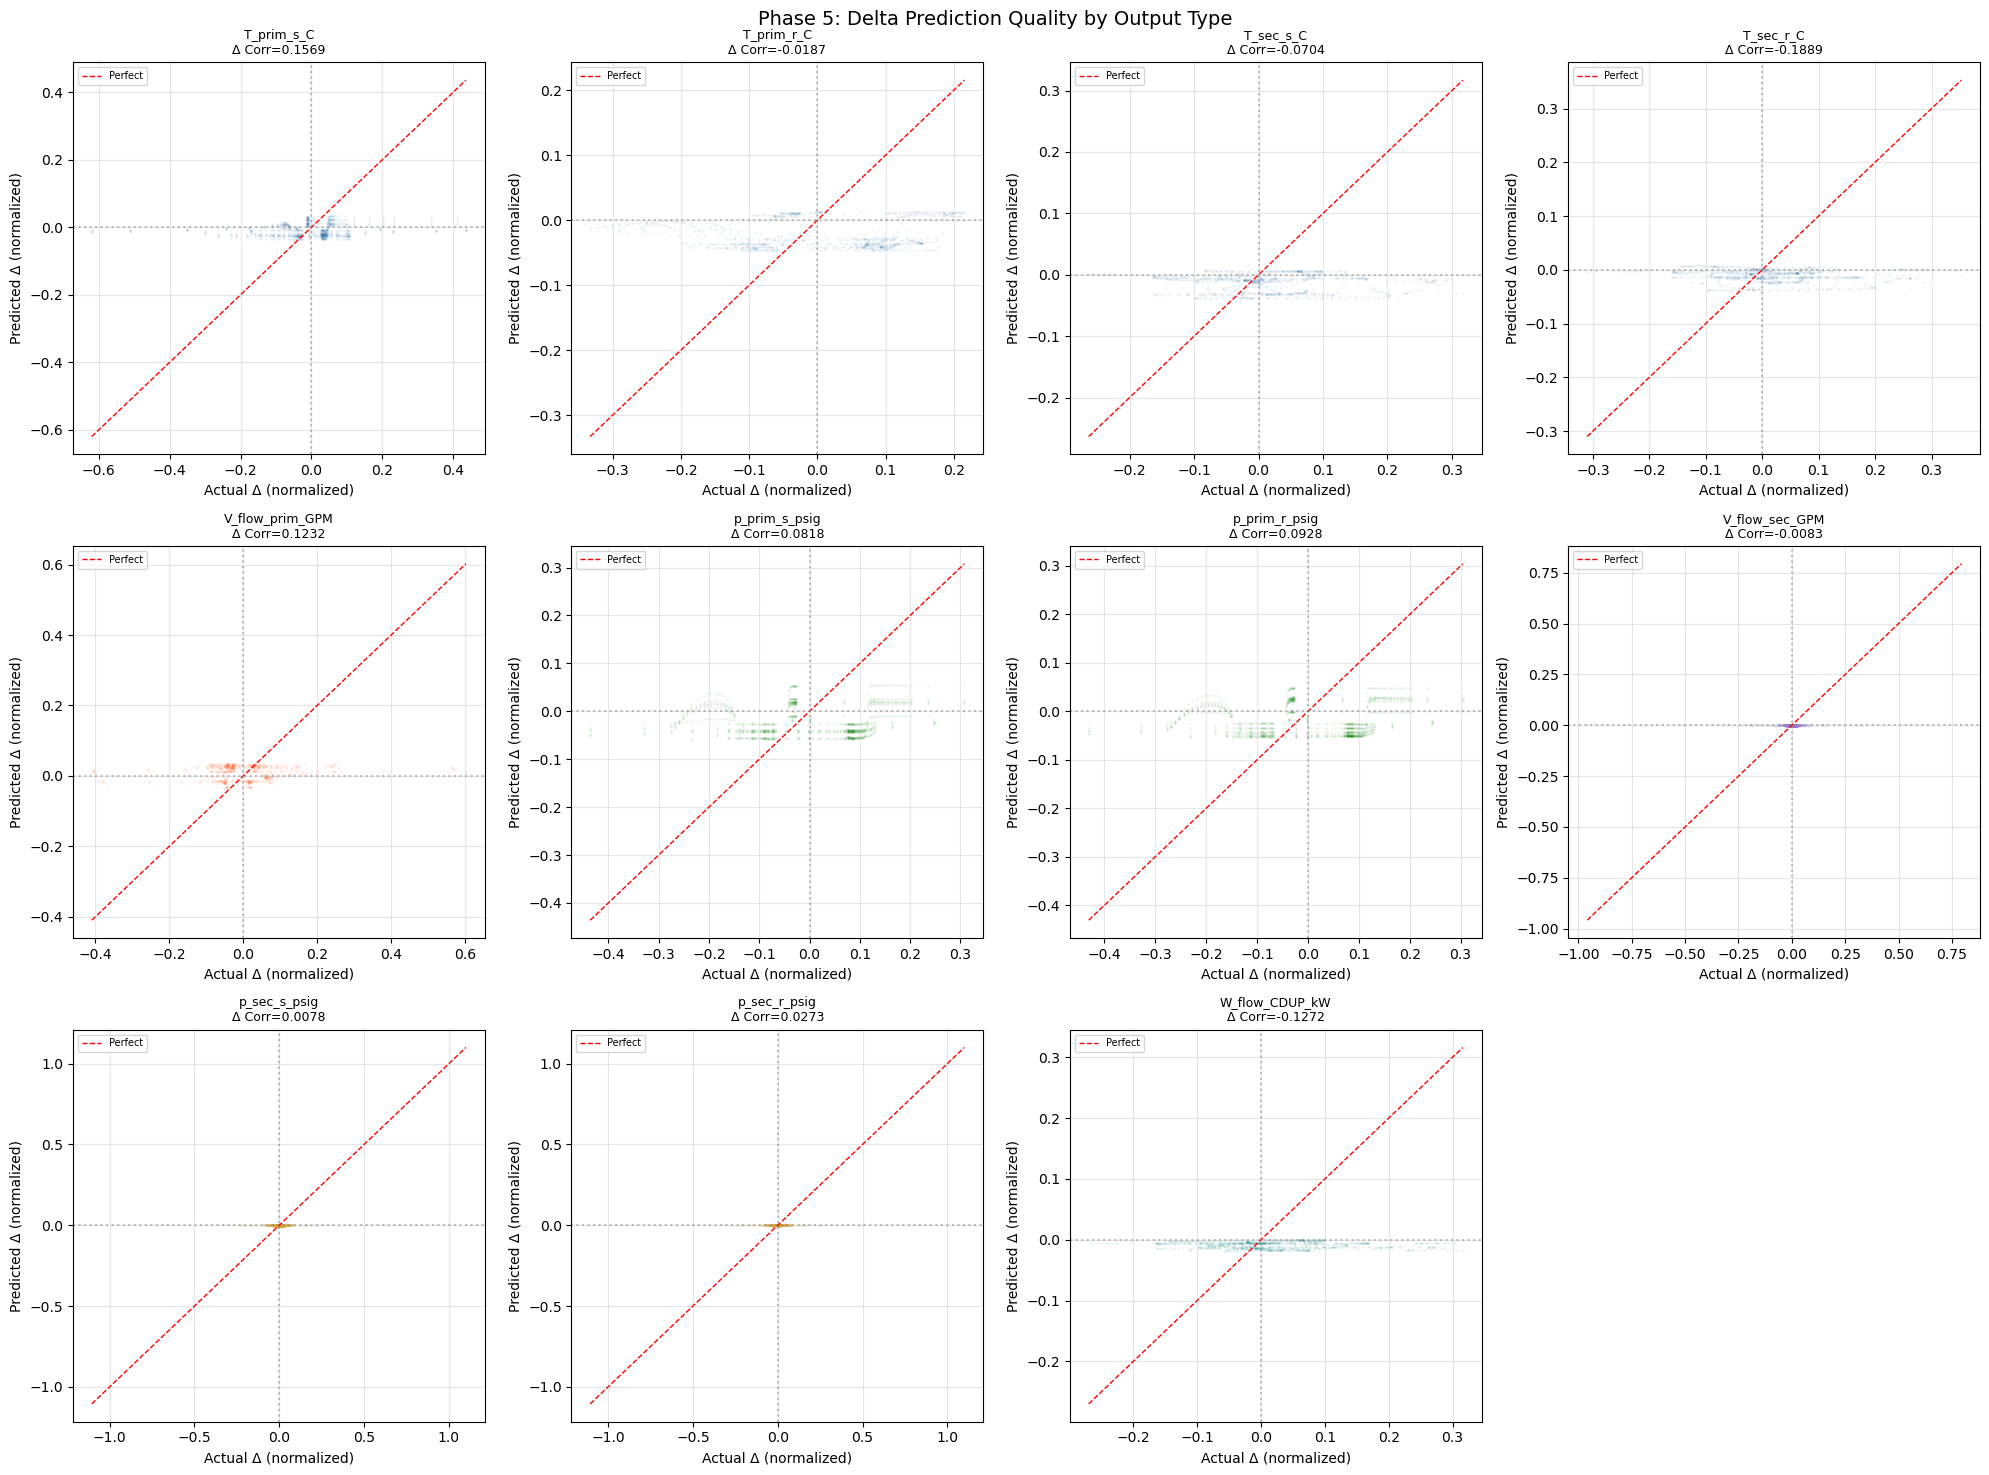

In [ ]:
#  Visualization 9 — Delta Prediction Quality

pred_norm = predictions_dict['pred_normalized']    # (N, K, n_dynamic)
tgt_norm = predictions_dict['target_normalized']   # (N, K, n_dynamic)

n_types = len(output_types)
ncols = 4
nrows = (n_types + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for idx, otype in enumerate(output_types):
    ax = axes[idx]
    type_cols = [i for i, col in enumerate(column_info['dynamic_cols'])
                 if otype in col]
    if not type_cols:
        ax.set_visible(False)
        continue

    sample_cols = type_cols[::max(1, len(type_cols)//5)]
    pred_deltas = pred_norm[:, :, sample_cols].flatten()
    tgt_deltas = tgt_norm[:, :, sample_cols].flatten()

    ax.scatter(tgt_deltas, pred_deltas, alpha=0.05, s=1,
               color=group_colors_map.get(
                   metrics_df[metrics_df['Output_Type'] == otype]['Group'].iloc[0], 'gray'))
    lims = [min(tgt_deltas.min(), pred_deltas.min()),
            max(tgt_deltas.max(), pred_deltas.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect')
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)

    corr = np.corrcoef(tgt_deltas, pred_deltas)[0, 1] if len(tgt_deltas) > 1 else 0
    ax.set_title(f'{otype}\n\u0394 Corr={corr:.4f}', fontsize=9)
    ax.set_xlabel('Actual \u0394 (normalized)')
    ax.set_ylabel('Predicted \u0394 (normalized)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(n_types, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Phase 5: Delta Prediction Quality by Output Type', fontsize=14)
plt.tight_layout()
plt.savefig('phase_5_vis/delta_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Time-Series Predictions (300-second sample)

Visualize model predictions vs actual values over a 300-second window (10 consecutive time steps at Δt=30s) for each output type. Includes persistence baseline for comparison.

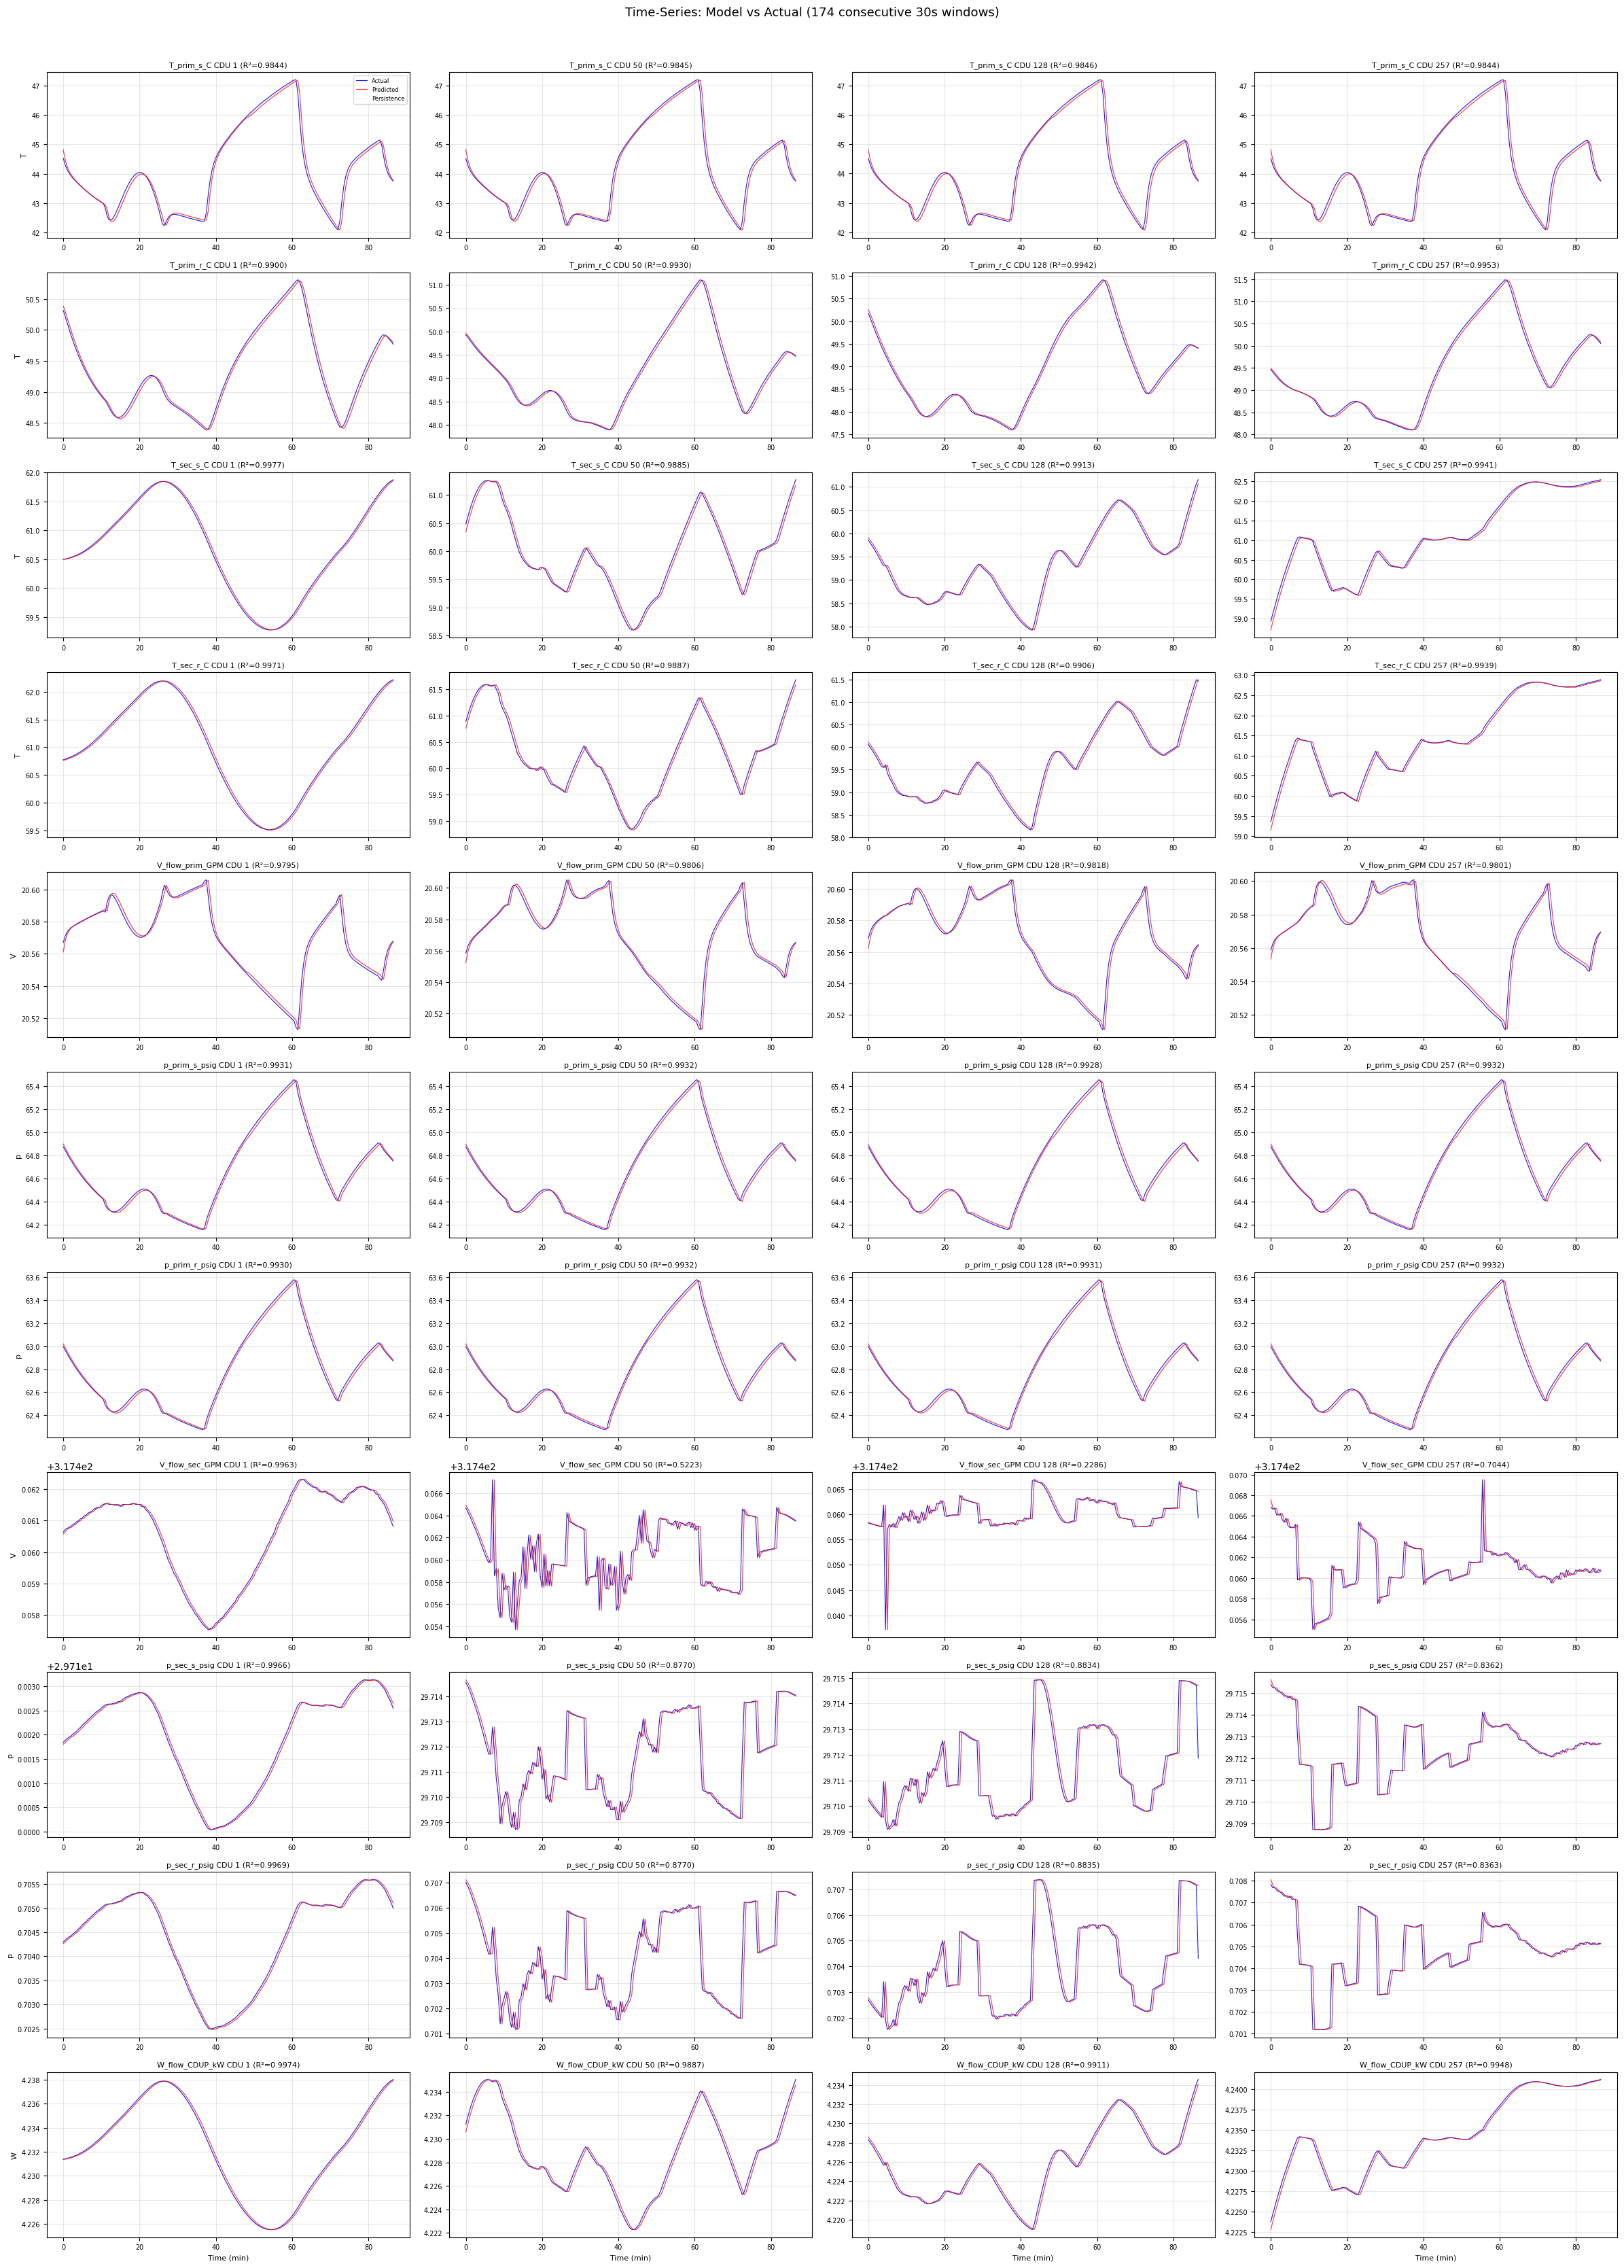

In [ ]:
#  Time-Series Predictions — Chain consecutive prediction windows
# (matching dl_12_federated_DeepM&Mnet.ipynb style)

def plot_timeseries_predictions(predictions_dict, column_info, config,
                                 n_cdus=4, n_samples_show=200):
    """
    Chain consecutive 30-sec prediction windows into a continuous time-series
    for every output type × selected CDUs.
    """
    pred = predictions_dict['pred_absolute']      # (N, K, n_dynamic)
    target = predictions_dict['target_absolute']   # (N, K, n_dynamic)
    last_dyn = predictions_dict['last_dynamic']    # (N, n_dynamic)
    dynamic_cols = column_info['dynamic_cols']

    output_types_list = config.ALL_DYNAMIC_OUTPUTS
    n_types = len(output_types_list)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR   # 30s per step

    N = min(n_samples_show, pred.shape[0])
    cdu_ids = [1, 50, 128, 257][:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.0 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(output_types_list):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            # Find column index in dynamic_cols
            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in dynamic_cols:
                ax.set_visible(False)
                continue
            idx = dynamic_cols.index(col_name)

            # Build time-series from consecutive prediction windows
            t_actual, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_actual.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_dyn[i, idx])

            t_min = np.array(t_actual) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Compute R² for this specific output
            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id} (R²={r2:.4f})', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type.split('_')[0], fontsize=8)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Time-Series: Model vs Actual ({N} consecutive {K*dt}s windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_5_vis/timeseries_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_predictions(predictions_dict, column_info, config)

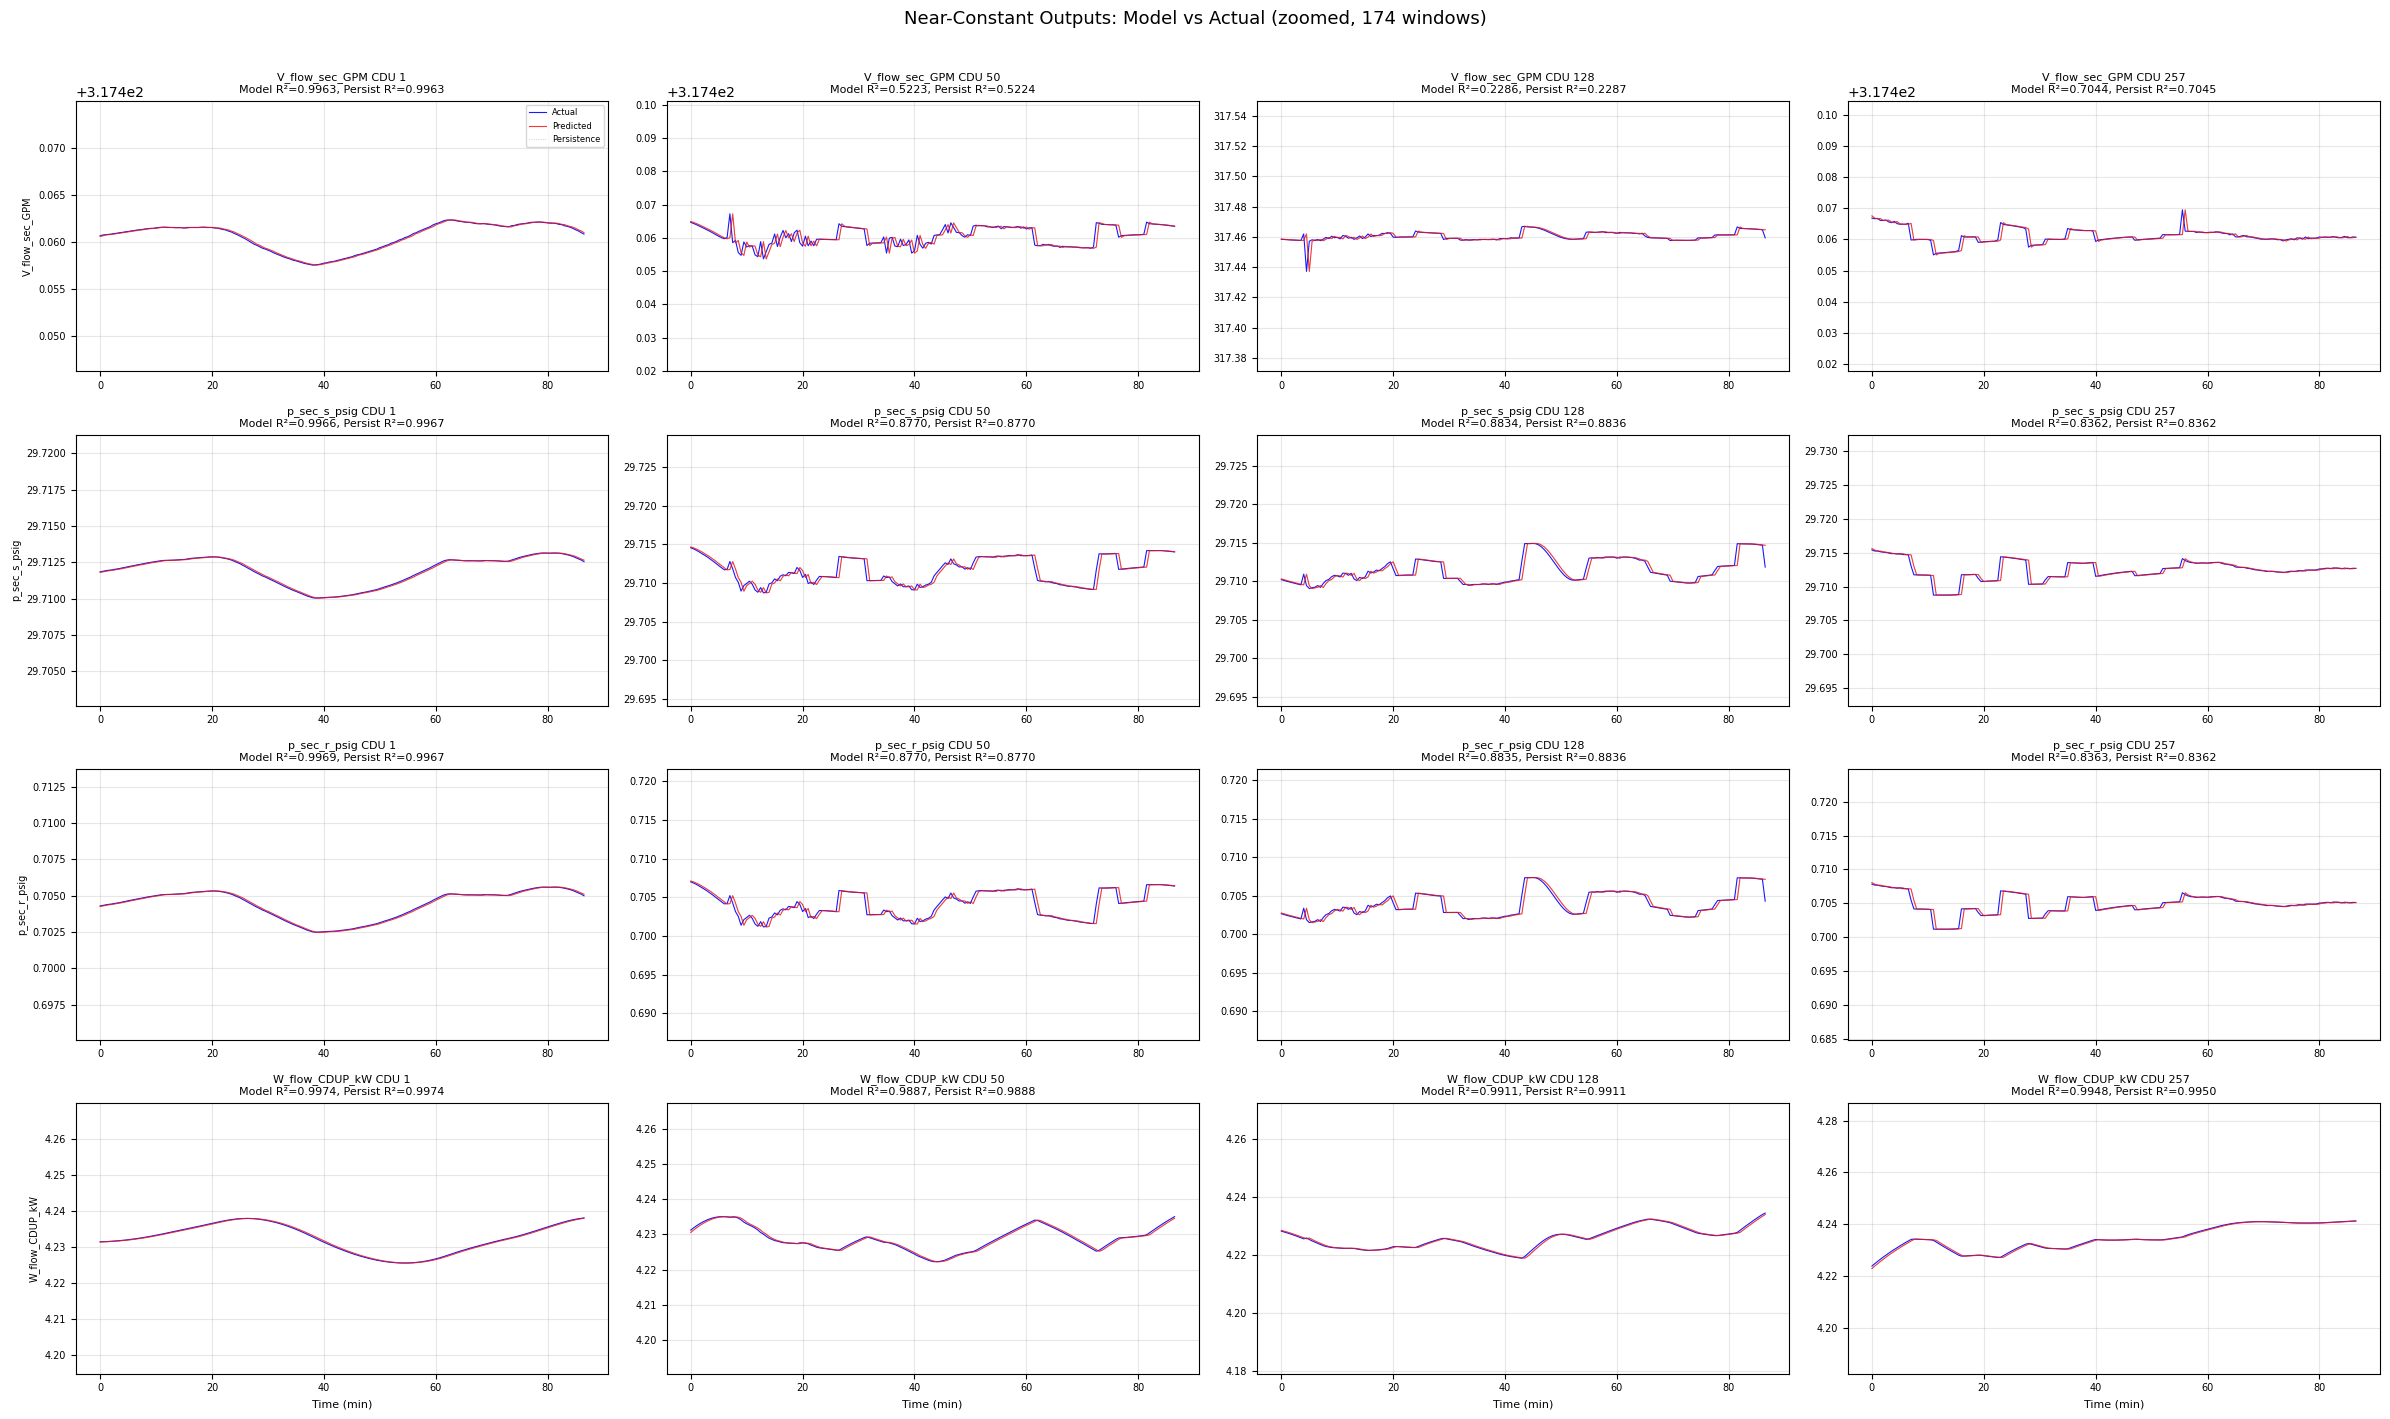

In [ ]:
#  Near-Constant Output Time-Series (Zoomed)
# (matching dl_12_federated_DeepM&Mnet.ipynb style)

def plot_timeseries_nearconst(predictions_dict, column_info, config,
                               n_cdus=4, n_samples_show=200):
    """
    Dedicated time-series for near-constant outputs (G_Vs, G_ps, G_W).
    Y-axis zoomed to ±3× data range for visibility of tiny fluctuations.
    """
    pred = predictions_dict['pred_absolute']
    target = predictions_dict['target_absolute']
    last_dyn = predictions_dict['last_dynamic']
    dynamic_cols = column_info['dynamic_cols']

    nearconst_types = (config.FLOW_SEC_OUTPUTS +
                       config.PRESSURE_SEC_OUTPUTS + config.POWER_OUTPUTS)
    n_types = len(nearconst_types)
    K = config.PREDICTION_STEPS
    dt = config.SUBSAMPLE_FACTOR
    N = min(n_samples_show, pred.shape[0])

    cdu_ids = [1, 50, 128, 257][:n_cdus]

    fig, axes = plt.subplots(n_types, n_cdus, figsize=(6 * n_cdus, 3.5 * n_types),
                             squeeze=False)

    for row, output_type in enumerate(nearconst_types):
        for col_idx, cdu_id in enumerate(cdu_ids):
            ax = axes[row, col_idx]

            pattern = config.OUTPUT_PATTERNS[output_type]
            col_name = pattern.format(cdu_id)
            if col_name not in dynamic_cols:
                ax.set_visible(False)
                continue
            idx = dynamic_cols.index(col_name)

            t_actual, y_actual, y_pred, y_persist = [], [], [], []
            for i in range(N):
                for k in range(K):
                    t_sec = (i * K + k) * dt
                    t_actual.append(t_sec)
                    y_actual.append(target[i, k, idx])
                    y_pred.append(pred[i, k, idx])
                    y_persist.append(last_dyn[i, idx])

            t_min = np.array(t_actual) / 60.0
            y_actual = np.array(y_actual)
            y_pred = np.array(y_pred)
            y_persist = np.array(y_persist)

            ax.plot(t_min, y_actual, 'b-', label='Actual', linewidth=0.8, alpha=0.9)
            ax.plot(t_min, y_pred, 'r-', label='Predicted', linewidth=0.8, alpha=0.8)
            ax.plot(t_min, y_persist, 'gray', linestyle=':', label='Persistence',
                    linewidth=0.6, alpha=0.5)

            # Zoom to ±3× range for visibility
            y_mean = y_actual.mean()
            y_range = max(y_actual.max() - y_actual.min(), 1e-4)
            margin = y_range * 3
            ax.set_ylim(y_mean - margin, y_mean + margin)

            ss_res = np.sum((y_actual - y_pred) ** 2)
            ss_tot = np.sum((y_actual - y_actual.mean()) ** 2)
            r2 = 1 - ss_res / (ss_tot + 1e-10)

            ss_res_p = np.sum((y_actual - y_persist) ** 2)
            r2_p = 1 - ss_res_p / (ss_tot + 1e-10)

            ax.set_title(f'{output_type} CDU {cdu_id}\nModel R²={r2:.4f}, '
                         f'Persist R²={r2_p:.4f}', fontsize=8)
            if col_idx == 0:
                ax.set_ylabel(output_type, fontsize=7)
            if row == n_types - 1:
                ax.set_xlabel('Time (min)', fontsize=8)
            if row == 0 and col_idx == 0:
                ax.legend(fontsize=6, loc='upper right')
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'Near-Constant Outputs: Model vs Actual (zoomed, {N} windows)',
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.savefig('phase_5_vis/timeseries_nearconst.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_timeseries_nearconst(predictions_dict, column_info, config)

## Save Results

Save model checkpoint, metrics, training history, and normalizer states for reproducibility and cross-phase comparison.

In [ ]:
#  Save Results

import json

save_dir = 'saved_models/phase5_federated'
os.makedirs(save_dir, exist_ok=True)

# 1. Model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': {
        'HISTORY_SECONDS': config.HISTORY_SECONDS,
        'SUBSAMPLE_FACTOR': config.SUBSAMPLE_FACTOR,
        'PREDICTION_STEPS': config.PREDICTION_STEPS,
        'BRANCH_HIDDEN': config.BRANCH_HIDDEN,
        'TBRANCH_HIDDEN': config.TBRANCH_HIDDEN,
        'LSTM_LAYERS': config.LSTM_LAYERS,
        'N_FOURIER_FREQ': config.N_FOURIER_FREQ,
        'TRUNK_HIDDEN': config.TRUNK_HIDDEN,
        'N_BASIS': config.N_BASIS,
        'DECODER_HIDDEN': config.DECODER_HIDDEN,
        'DECODER_HIDDEN_SMALL': config.DECODER_HIDDEN_SMALL,
        'PHASE1_EPOCHS': config.PHASE1_EPOCHS,
        'PHASE2_EPOCHS': config.PHASE2_EPOCHS,
        'LEARNING_RATE': config.LEARNING_RATE,
        'DROPOUT': config.DROPOUT,
    },
    'column_info': column_info,
    'total_params': total_params,
    'n_inputs': n_inputs,
    'n_dynamic': n_dynamic,
}
torch.save(checkpoint, os.path.join(save_dir, 'phase5_model.pt'))
print(f"Model checkpoint saved to {save_dir}/phase5_model.pt")

# 2. Training history
history = {
    'phase1': phase1_history,
    'phase2': phase2_history,
    'phase1_epochs': phase1_epochs,
    'phase2_epochs': phase2_epochs,
    'phase1_time': phase1_time,
    'phase2_time': phase2_time,
    'total_train_time': total_train_time,
}
with open(os.path.join(save_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2, default=str)
print("Training history saved")

# 3. Metrics
metrics_df.to_csv(os.path.join(save_dir, 'phase5_metrics.csv'), index=False)
print(f"Metrics saved: {len(metrics_df)} outputs")

# 4. Normalizer states
normalizer_state = {
    # 'input_mean': normalizer.input_normalizer.mean.tolist(),
    # 'input_std': normalizer.input_normalizer.std.tolist(),
    # 'delta_mean': normalizer.delta_normalizer.mean.tolist(),
    # 'delta_std': normalizer.delta_normalizer.std.tolist(),
}
with open(os.path.join(save_dir, 'normalizer_states.json'), 'w') as f:
    json.dump(normalizer_state, f, indent=2)
print("Normalizer states saved")

# 5. Predictions (compressed)
np.savez_compressed(
    os.path.join(save_dir, 'phase5_predictions.npz'),
    pred_absolute=predictions_dict['pred_absolute'],
    target_absolute=predictions_dict['target_absolute'],
    pred_normalized=predictions_dict['pred_normalized'],
    target_normalized=predictions_dict['target_normalized'],
    last_dynamic=predictions_dict['last_dynamic'],
)
print("Predictions saved (compressed)")
print(f"\nAll results saved to {save_dir}/")

Model checkpoint saved to saved_models/phase5_federated/phase5_model.pt
Training history saved
Metrics saved: 2827 outputs
Normalizer states saved
Predictions saved (compressed)

All results saved to saved_models/phase5_federated/


In [ ]:
#  Final Summary

print("=" * 80)
print("PHASE 5: FEDERATED DEEPM&MNET — FINAL SUMMARY")
print("=" * 80)

print("\n--- Architecture ---")
print(f"  Shared Encoder: Branch LSTM ({config.BRANCH_HIDDEN}h, {config.LSTM_LAYERS}L) "
      f"+ TBranch LSTM ({config.TBRANCH_HIDDEN}h, {config.LSTM_LAYERS}L) "
      f"+ Fourier Trunk ({config.N_FOURIER_FREQ} freq, {config.TRUNK_HIDDEN}h)")
print(f"  Fusion: Hadamard product z[k] = b ⊙ tb ⊙ T[k]")
print(f"  Decoder Heads:")
ALL_HEAD_NAMES = ['G_T', 'G_V', 'G_p', 'G_Vs', 'G_ps', 'G_W']
for name in ALL_HEAD_NAMES:
    group_info = column_info['head_groups'][name]
    n_out = len(group_info['cols'])
    head_type = group_info['type']
    group_metrics = metrics_df[metrics_df['Group'] == name]
    mean_r2 = group_metrics['R2'].mean()
    print(f"    {name}: {head_type} head, {n_out} outputs, mean R²={mean_r2:.4f}")
print(f"  Total Parameters: {total_params:,}")

print(f"\n--- Training ---")
print(f"  Phase 1 (Round-Robin): {phase1_epochs} epochs, {phase1_time:.1f}s")
print(f"  Phase 2 (Joint Fine-Tuning): {phase2_epochs} epochs, {phase2_time:.1f}s")
print(f"  Total Training Time: {total_train_time:.1f}s ({total_train_time/60:.1f} min)")
print(f"  Total Epochs: {phase1_epochs + phase2_epochs}")

print(f"\n--- Data ---")
print(f"  Dataset: systematic_fmu_output_11hrs.parquet")
print(f"  Inputs: {n_inputs} features, Outputs: {n_dynamic} dynamic outputs")
print(f"  History: {config.HISTORY_SECONDS}s ({config.HISTORY_SECONDS // config.SUBSAMPLE_FACTOR} steps)")
print(f"  Prediction: K={config.PREDICTION_STEPS} step ({config.PREDICTION_STEPS * config.SUBSAMPLE_FACTOR}s)")
print(f"  Subsample: {config.SUBSAMPLE_FACTOR}s")

print(f"\n--- Overall Performance ---")
print(f"  Mean R²: {metrics_df['R2'].mean():.4f} ± {metrics_df['R2'].std():.4f}")
print(f"  Median R²: {metrics_df['R2'].median():.4f}")
print(f"  Mean RMSE: {metrics_df['RMSE'].mean():.6f}")
print(f"  Mean MAE: {metrics_df['MAE'].mean():.6f}")
print(f"  Mean Correlation: {metrics_df['Correlation'].mean():.4f}")
print(f"  Mean Variance Ratio: {metrics_df['Variance_Ratio'].mean():.4f}")

print(f"\n--- Primary vs Secondary Loop ---")
primary = metrics_df[metrics_df['Loop'] == 'primary']
secondary = metrics_df[metrics_df['Loop'] == 'secondary']
print(f"  Primary Loop: {len(primary)} outputs, mean R²={primary['R2'].mean():.4f}")
print(f"  Secondary Loop: {len(secondary)} outputs, mean R²={secondary['R2'].mean():.4f}")
print(f"  Primary beats persistence: {primary['Beats_Persistence'].mean()*100:.1f}%")
print(f"  Secondary beats persistence: {secondary['Beats_Persistence'].mean()*100:.1f}%")

print(f"\n--- Near-Constant Outputs ---")
for otype in ['V_flow_sec_GPM', 'p_sec_s_psig', 'p_sec_r_psig', 'W_flow_CDUP_kW']:
    subset = metrics_df[metrics_df['Output_Type'] == otype]
    if len(subset) > 0:
        print(f"  {otype}: mean R²={subset['R2'].mean():.4f}, "
              f"beats persistence={subset['Beats_Persistence'].mean()*100:.1f}%")

print(f"\n--- Computational Performance ---")
print(f"  Inference Time: {inference_time:.2f}s for {n_test_samples} samples")
print(f"  Throughput: {n_test_samples/inference_time:.1f} samples/sec")
print(f"  Device: {DEVICE}")

print(f"\n--- R² Distribution ---")
for threshold in [0.99, 0.95, 0.90, 0.80, 0.50]:
    count = (metrics_df['R2'] >= threshold).sum()
    pct = count / len(metrics_df) * 100
    print(f"  R² ≥ {threshold}: {count}/{len(metrics_df)} ({pct:.1f}%)")

print("\n" + "=" * 80)
print("Phase 5 notebook complete.")
print("=" * 80)

PHASE 5: FEDERATED DEEPM&MNET — FINAL SUMMARY

--- Architecture ---
  Shared Encoder: Branch LSTM (128h, 2L) + TBranch LSTM (128h, 2L) + Fourier Trunk (8 freq, 64h)
  Fusion: Hadamard product z[k] = b ⊙ tb ⊙ T[k]
  Decoder Heads:
    G_T: standard head, 1028 outputs, mean R²=0.9924
    G_V: standard head, 257 outputs, mean R²=0.9810
    G_p: standard head, 514 outputs, mean R²=0.9931
    G_Vs: skip head, 257 outputs, mean R²=0.8123
    G_ps: skip head, 514 outputs, mean R²=0.9254
    G_W: skip head, 257 outputs, mean R²=0.9958
  Total Parameters: 3,113,756

--- Training ---
  Phase 1 (Round-Robin): 21 epochs, 65.0s
  Phase 2 (Joint Fine-Tuning): 21 epochs, 64.5s
  Total Training Time: 129.5s (2.2 min)
  Total Epochs: 42

--- Data ---
  Dataset: systematic_fmu_output_11hrs.parquet
  Inputs: 515 features, Outputs: 2827 dynamic outputs
  History: 1200s (40 steps)
  Prediction: K=1 step (30s)
  Subsample: 30s

--- Overall Performance ---
  Mean R²: 0.9632 ± 0.0720
  Median R²: 0.9926
  Mea